# Paper Figures

WT versus AA SEC-SAXS: measured frame averages first, baseline sensitivity, and a minimal WT EFA decomposition.

**These are publication-figure candidates with explicit processing choices—not a declaration of monomer purity or an identified WT multimer.** All frames are zero-based and inclusive. No curve smoothing, negative-intensity clipping, or fitted constant background is applied. Original HDF5 profiles are available before the notebook buffer subtraction; one estimated buffer is subtracted from them.

The primary panels use the documented reference buffers: **WT220–236; AA24–70**. Both pass our stationarity checks. This reference convention was retained to avoid selecting a subtraction for a desired Rg; it is not proof that these are uniquely correct buffers. Matched early, post, and linearly interpolated backgrounds remain mandatory sensitivity panels. AA210–220 fails stationarity and is a stress test only. No WT shoulder frames are used as buffer.

In [1]:
from pathlib import Path
import sys,json,numpy as np
from IPython.display import display,Image,Markdown
ROOT=Path.cwd()
if not (ROOT/'analysis').is_dir():
    raise RuntimeError('Run this notebook from the repository root.')
sys.path.insert(0,str(ROOT/'analysis'))
from paper_figures import run,figures
from paper_figures_controls import run_controls,control_figures,efa_progression,window_kratky
OUT=ROOT/'paper_figures'
RECOMPUTE=False # True reruns original-profile EFA, window selection, 100 perturbations, BIFT, and controls.
if RECOMPUTE:
    run(nboot=100)
    run_controls()
figures();control_figures();efa_progression();window_kratky()
rows=json.loads((OUT/'curve_results.json').read_text())
choices=json.loads((OUT/'choices.json').read_text())


## Four-panel WT–AA summary

WT is navy; AA is orange-red. The Guinier residuals occupy a separate panel immediately beneath the fits, sharing the q² axis. Dashed lines/crosses show conventional Guinier (G); solid lines/circles show extended Guinier (EG). Gray points lie outside the extended fit range.

Error bars represent propagated measurement uncertainties; normalized scattering and Kratky bands are conditional 95% intervals where available. Guinier legend uncertainties are fit standard errors; P(r) bands and legend uncertainties are local BIFT uncertainties. These do not include baseline-model uncertainty. The primary windows and buffers are unchanged; P(r) uses q = 0.012–0.25 Å⁻¹, with higher-q sensitivity below.

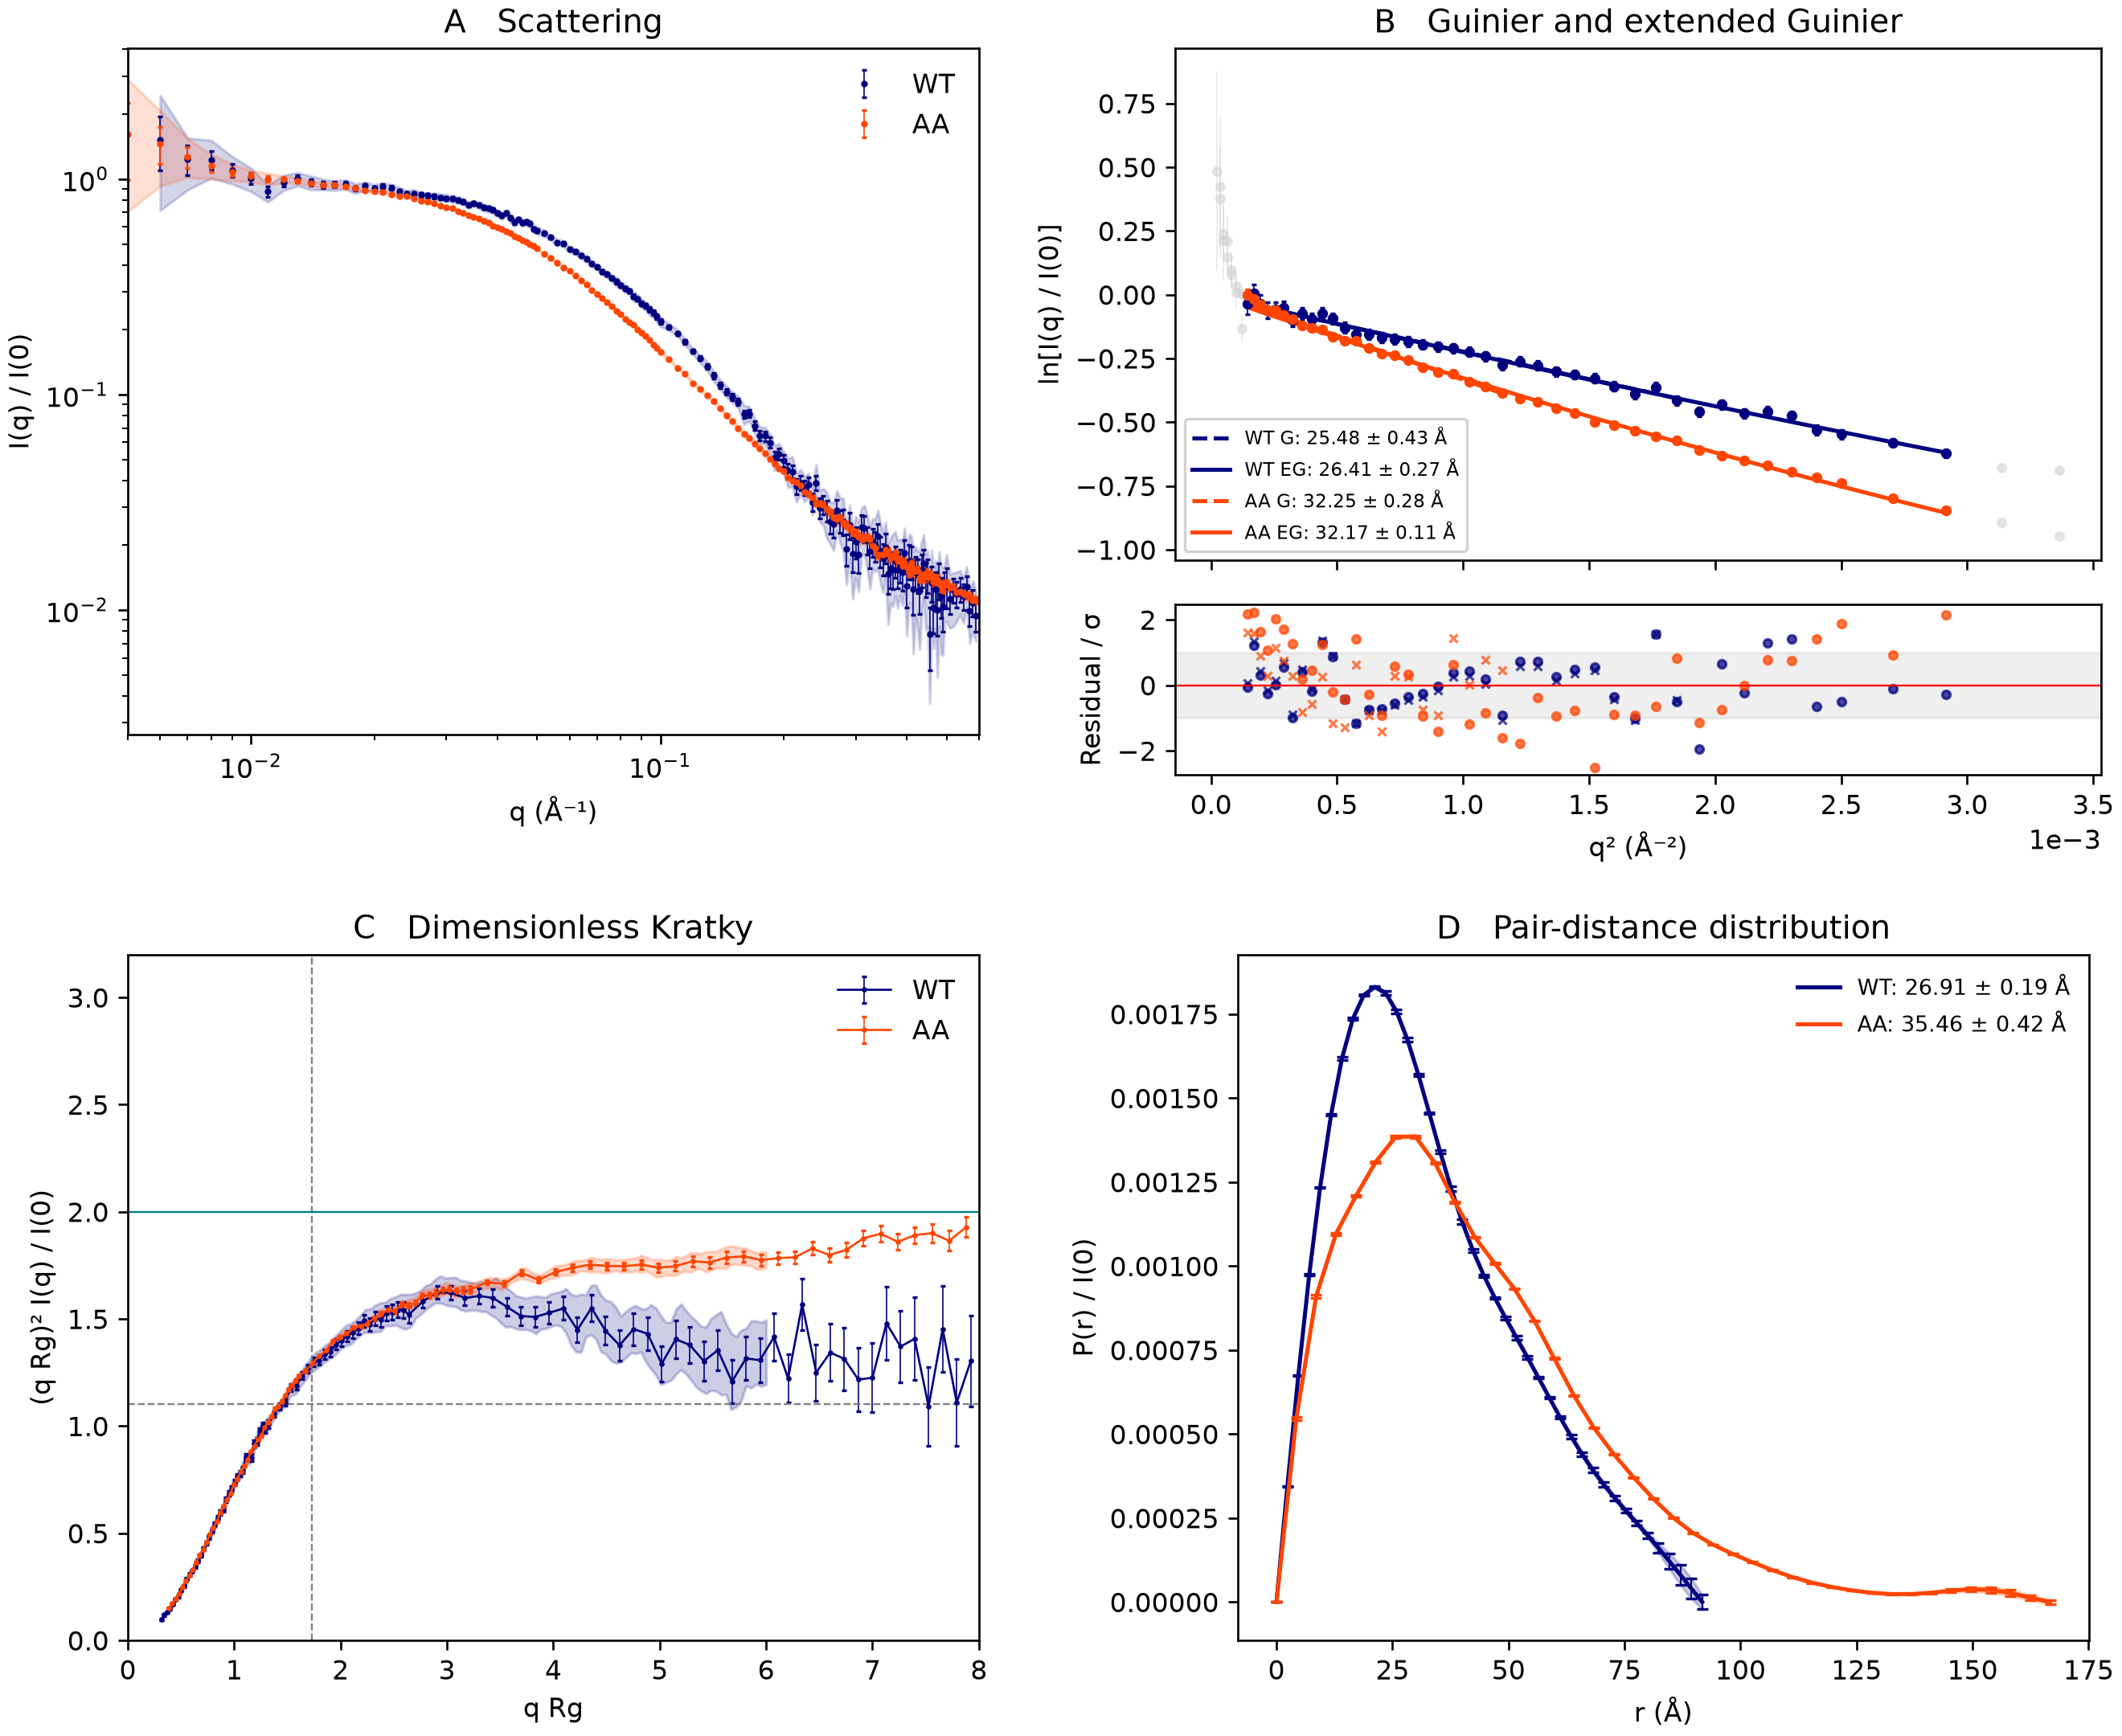

In [2]:
from paper_composite import composite, STYLE
composite()
display(Image(filename=str(STYLE/'WT_AA_four_panel.png')))

## Natalie’s figure format — errors and full scattering range

Formatting is based directly on the original [WT_092025 notebook](https://github.com/Natalie-Loui/BNL_SAXS/blob/main/WT_092025.ipynb) (plot cells47/51/56) and [AA_052026 notebook](https://github.com/Natalie-Loui/BNL_SAXS/blob/main/AA_052026.ipynb) (54/59/64): blue WT, orange AA, log–log I(q), and3:1Guinier/residual panels. Both conventional and extended fits are shown. Points outside each specified q-range are transparent; they are **excluded by range**, not removed as outliers. The fits and selected windows are unchanged.

**Error key:** I(q) and log-I points show propagated1σ measurement errors, including shared buffer uncertainty. Rg legends and the summary table show conditional fit SE. The bootstrap95% interval is separately labeled. Normalized I(q)/Kratky shaded bands include refitted I(0)/Rg uncertainty. P(r) errors and its Rg/Dmax errors are RAW BIFT's local model uncertainties; P(r)/I(0) pointwise bars hold its fitted normalization fixed. None of these small bars includes the separate baseline-model spread. In standardized residual panels, the±1bars show the input measurement uncertainty at fixed model.

The log–log I(q) overview now extends to0.6Å⁻¹, as in Natalie’s notebook, with a signed-intensity companion. The earlier0.25Å⁻¹overview was a crop, not the measured-data endpoint. Source profiles extend to3.19Å⁻¹; the0.6Å⁻¹display is explicit and does not imply all higher-q data are unusable. Guinier fit ranges stay low-q, as required by the approximations. Kratky uses Natalie’s qRg=0–8 display and reference lines at√3,3/e,and2; the signed high-q Kratky companion extends to0.6Å⁻¹.


WT EFA curve bars are1σ from refitted source-noise perturbations; elution bands are pointwise conditional95% intervals after normalizing each draw to its own peak. Fixed supports impose their zero boundaries. These bands do not include component-support or baseline-model uncertainty.

The standalone Guinier panels match the supplied screenshots: dark-blue WT/orange AA, gray excluded points,3:1panels and I(0)/index legends. Dashed extensions identify model extrapolation outside the fit; these points are not fitted. Index labels refer to the exported q array. Rg± values are conditional fit SE.

|Sample|Guinier Rg ± fit SE|Extended Rg ± fit SE|Extended bootstrap95%|P(r) Rg ± local BIFT σ|Dmax ± local BIFT σ|
|---|---:|---:|---|---:|---:|
|WT|25.48 ± 0.43|26.41 ± 0.27|[26.04, 26.89]|26.91 ± 0.19|91.7 ± 3.6|
|AA|32.25 ± 0.28|32.17 ± 0.11|[31.98, 32.39]|35.46 ± 0.42|166.7 ± 7.2|

All distances in Å. Local/conditional errors exclude baseline-model uncertainty.

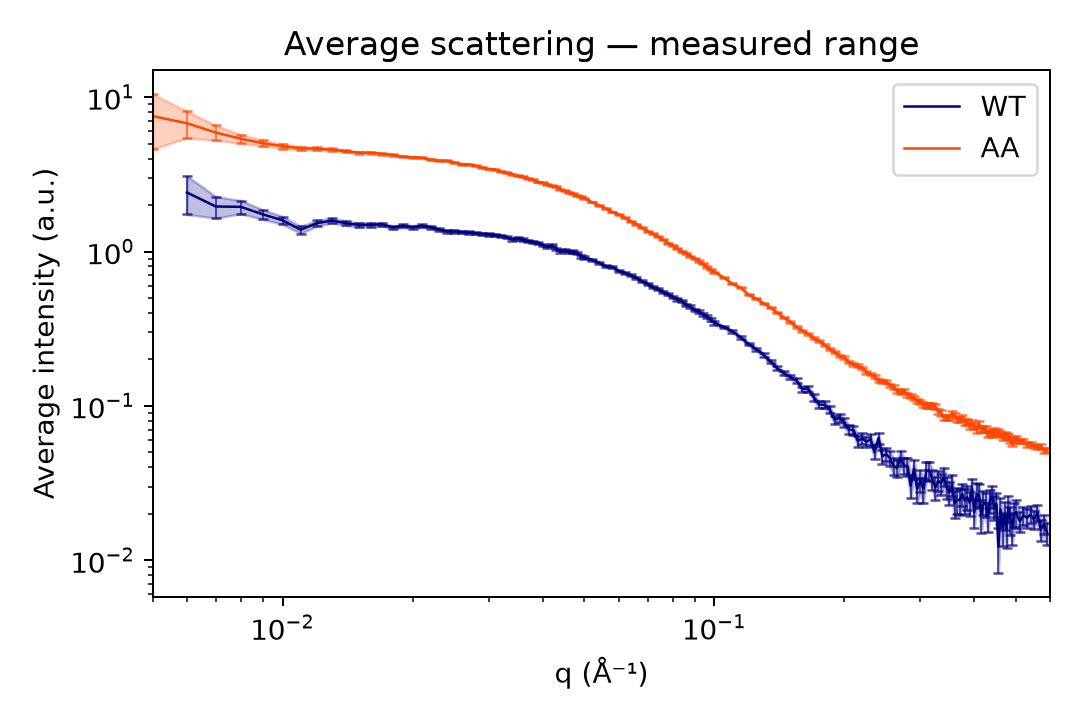

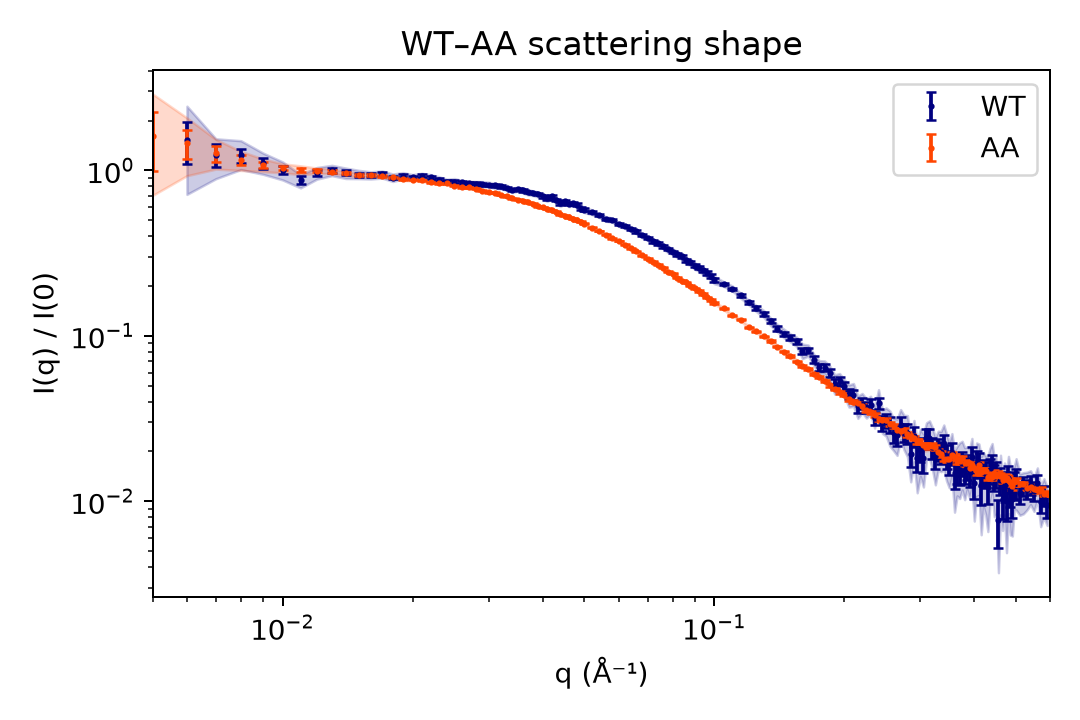

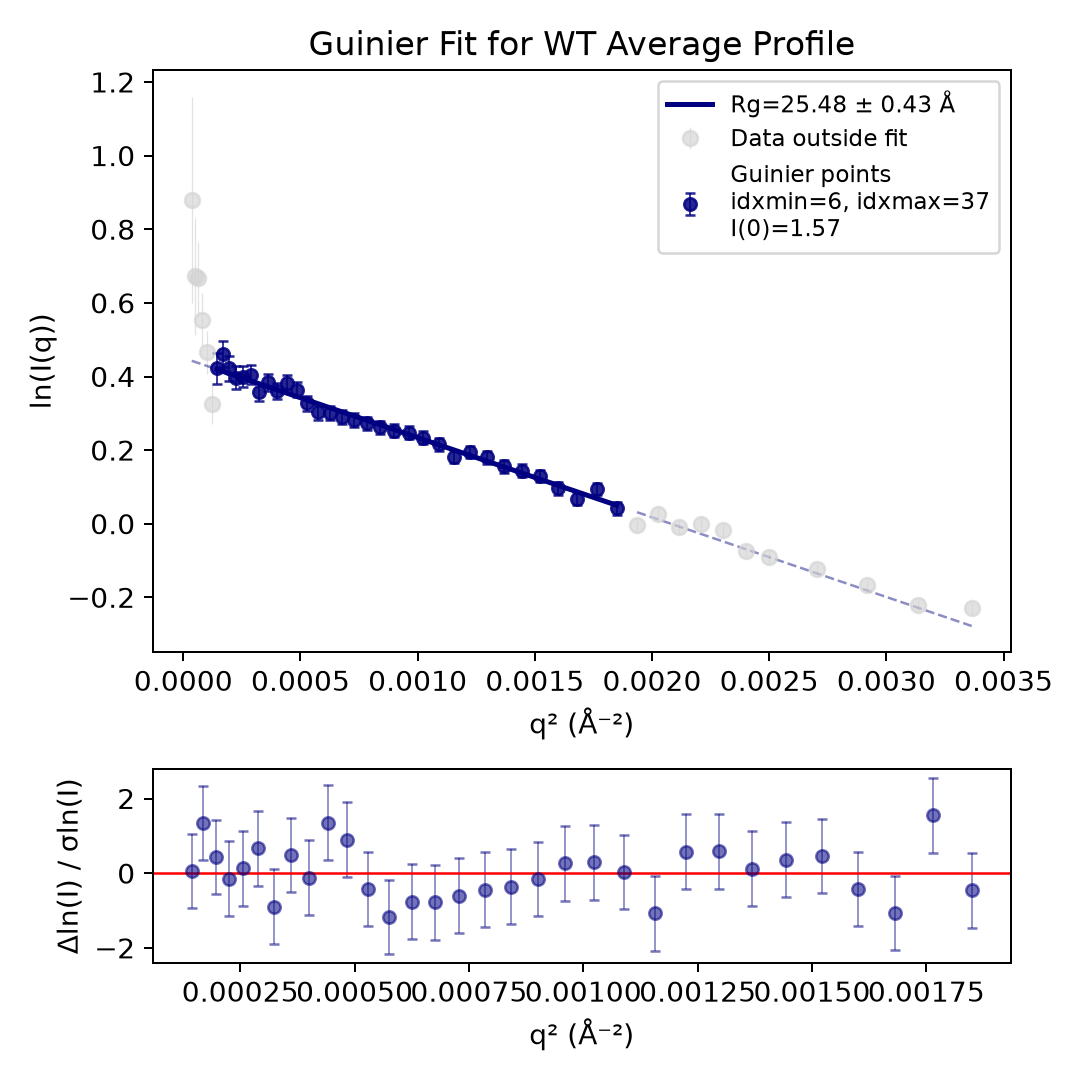

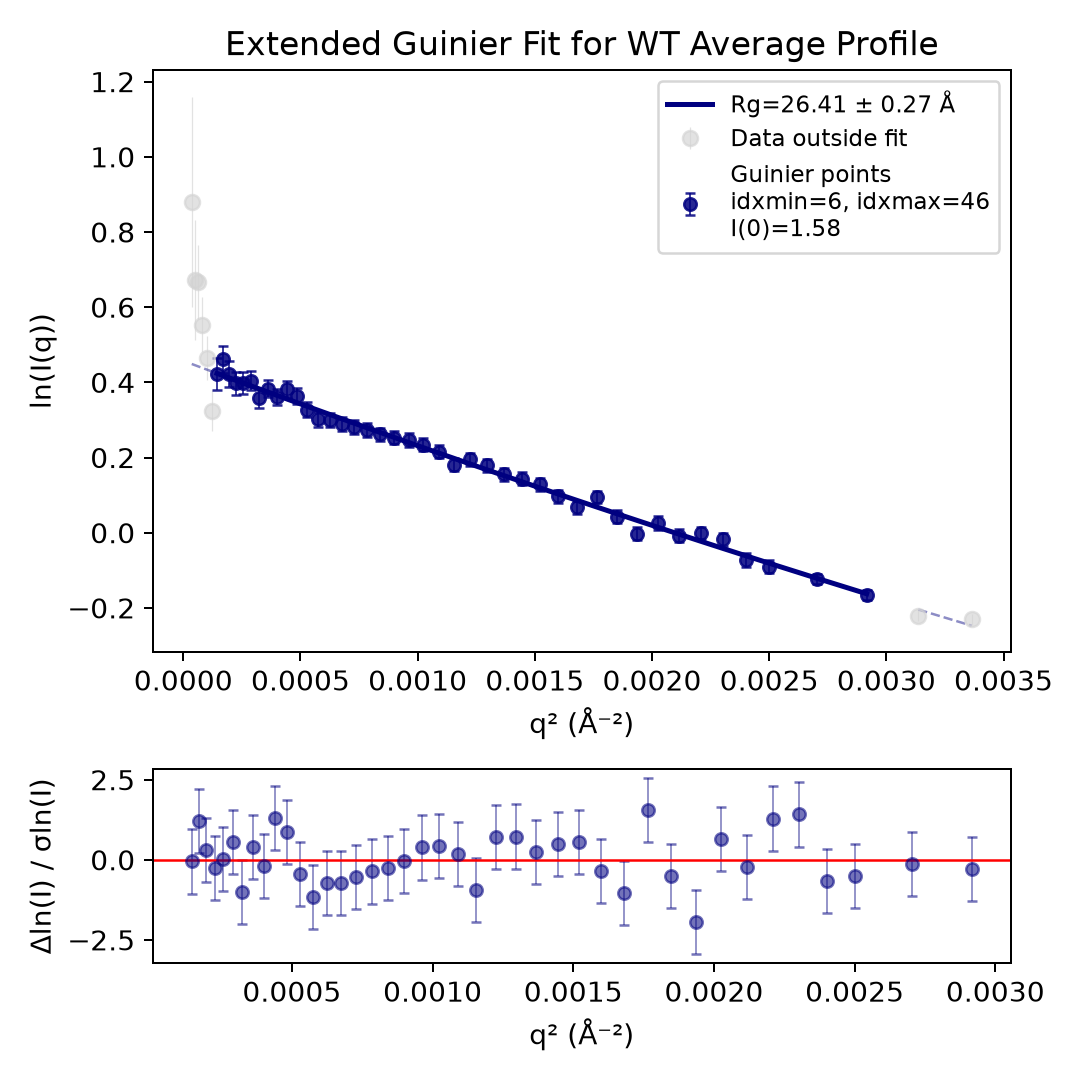

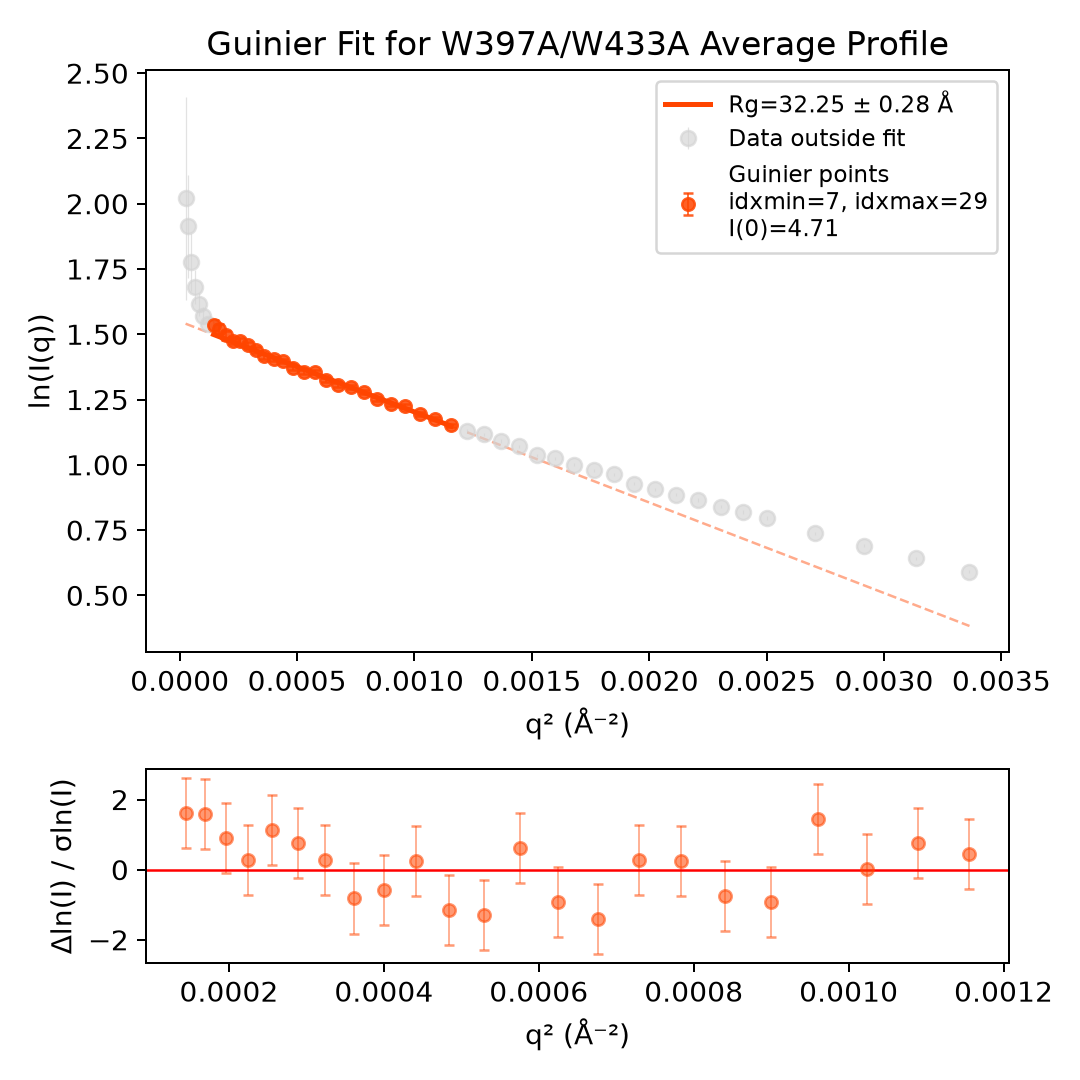

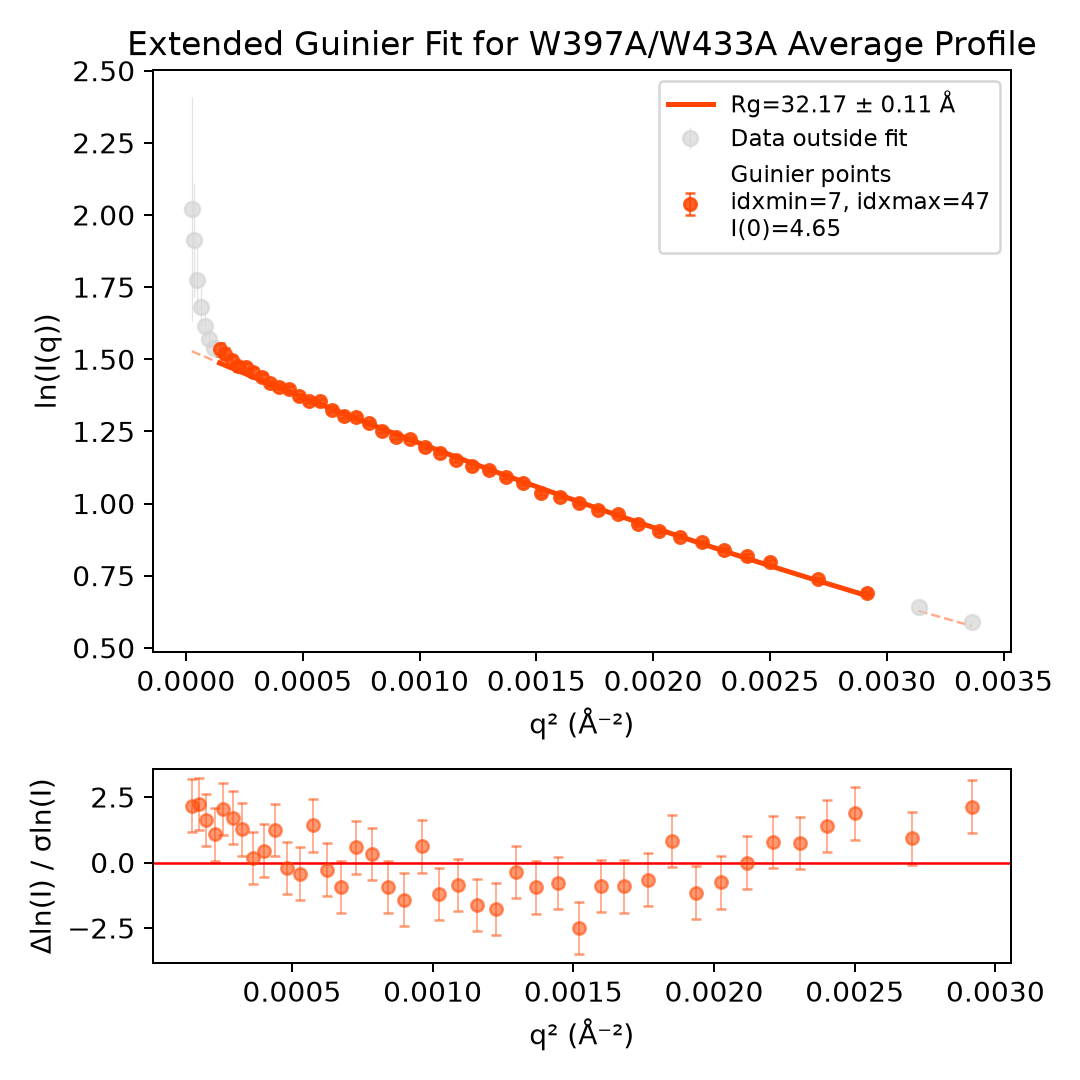

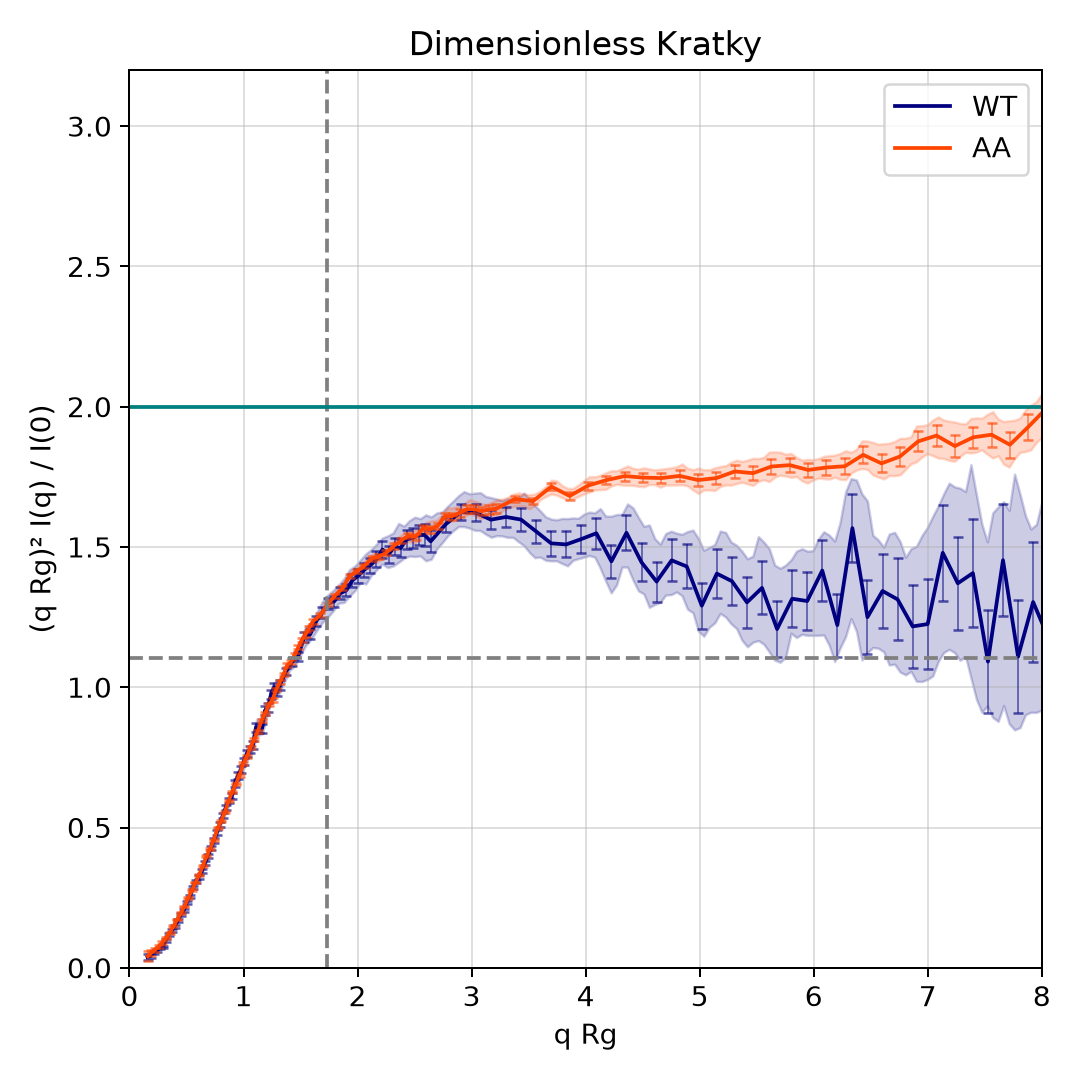

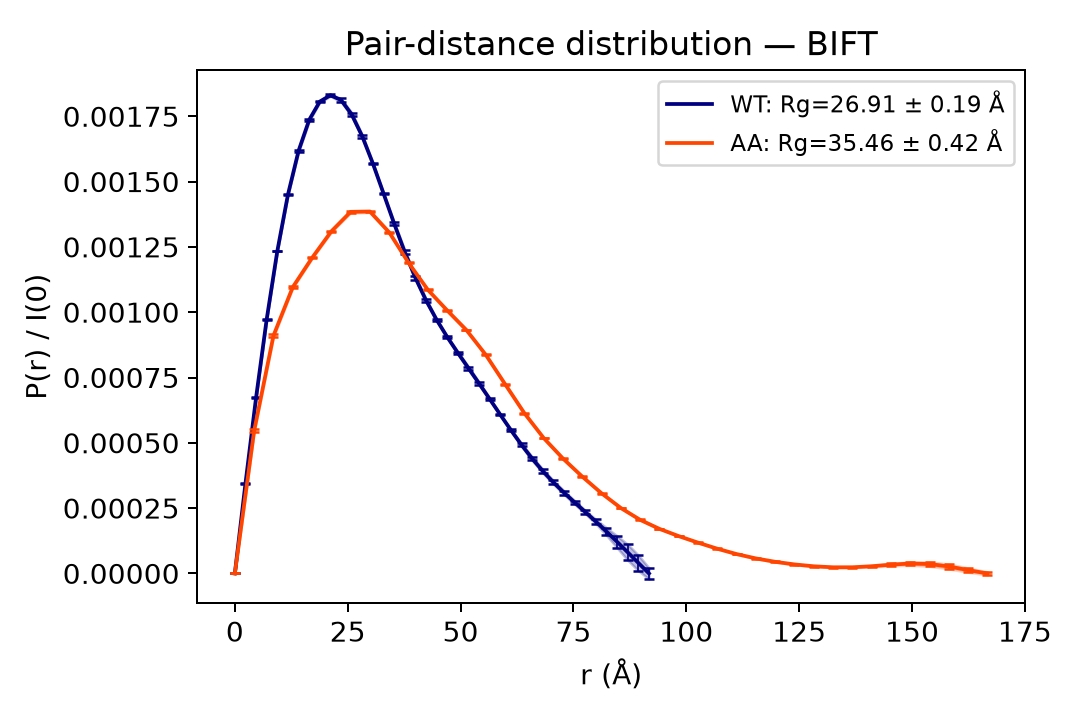

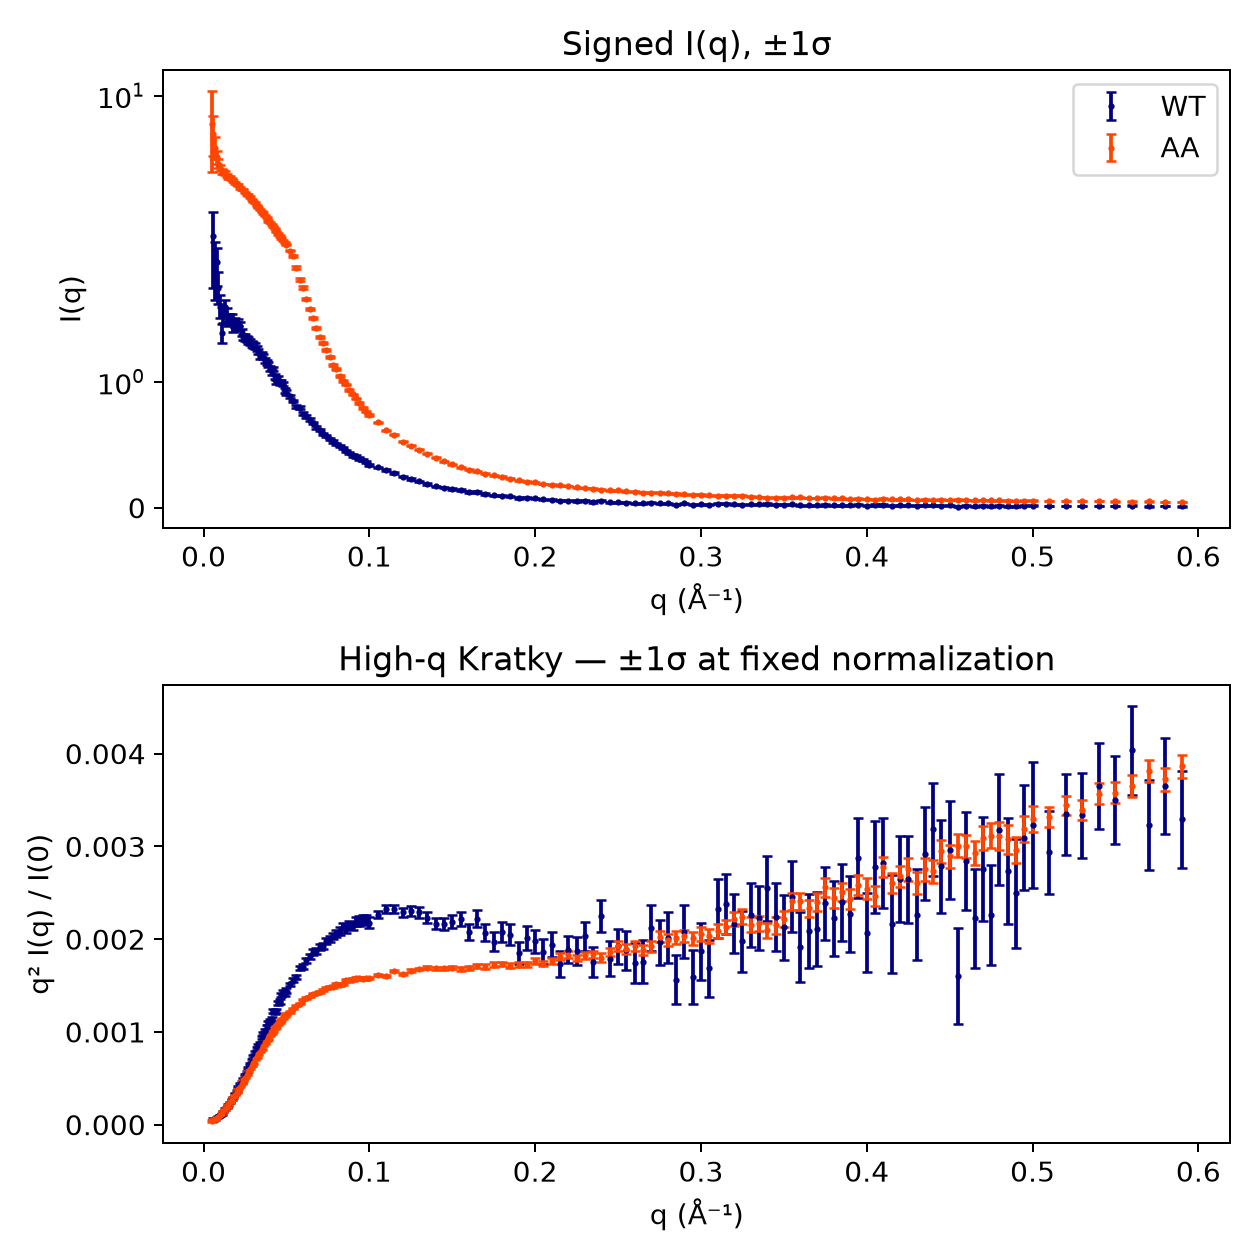

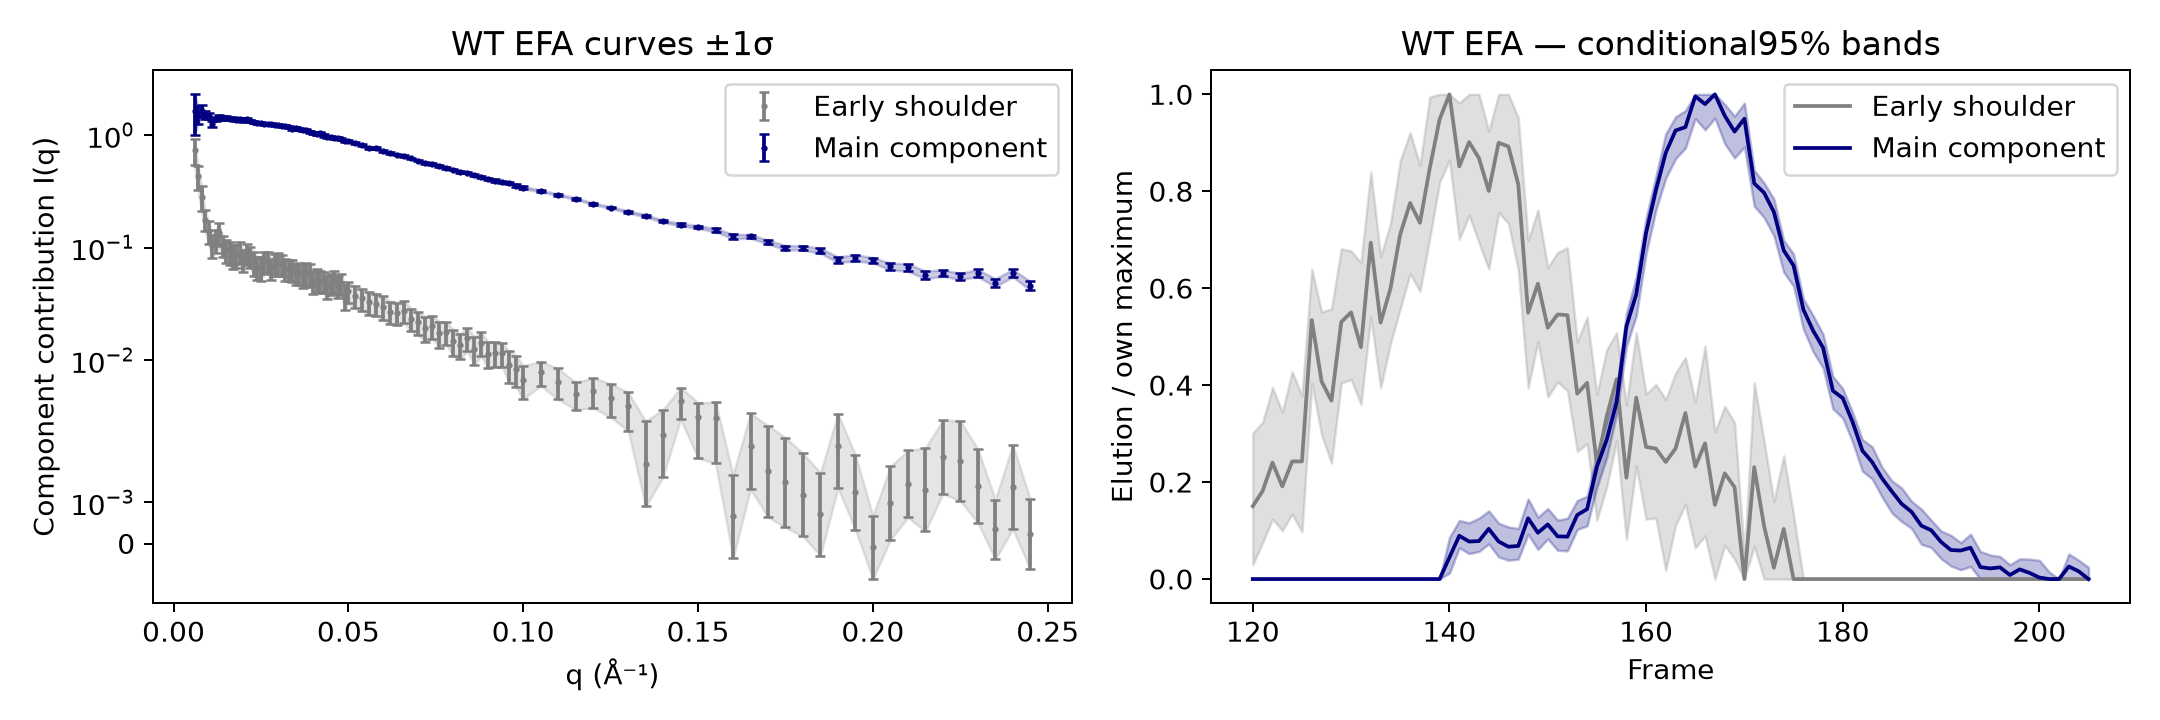

In [3]:
from natalie_style_figures import calculate,make,table,STYLE,efa_bands,efa_plot,reference_guinier
if RECOMPUTE or not (STYLE/'uncertainty_and_qmax.json').exists():
    calculate()
    efa_bands()
make();efa_plot();reference_guinier()
table()
for name in ['Iq','Iq_normalized','WT_conventional_reference','WT_extended_reference','AA_conventional_reference','AA_extended_reference','Kratky','Pr','high_q','WT_EFA']:
    display(Image(filename=str(STYLE/(name+'.png'))))


### Does including higher q change P(r)?

We reran BIFT with qmax0.25,0.35,0.50,and0.60Å⁻¹ using the same profiles and settings. WT is stable (Rg26.91→26.78Å). AA shifts more (35.46→33.08Å), and its inferred long-distance tail/Dmax changes. This is a real fit-range sensitivity that is larger than the local error bars; it should not be hidden by quoting only those bars. These tests do not by themselves establish which cutoff is correct. The primary0.25Å⁻¹ P(r) is retained for continuity and its broader-range alternatives are shown below. Intensity SNR alone cannot establish the accuracy of high-q subtraction.

**Why these P(r) curves can look smoother than Natalie’s:** there is no extra moving-average or smoothing filter applied after reconstruction. However, BIFT itself is a regularized inverse transform, here with40real-space points. Natalie uses GNOM with different Dmax/regularization settings. Different buffer, window and q-range choices also matter. We have not isolated their respective contributions with a same-input/same-settings GNOM comparison; smoother appearance is not evidence of a more accurate result or a better average.

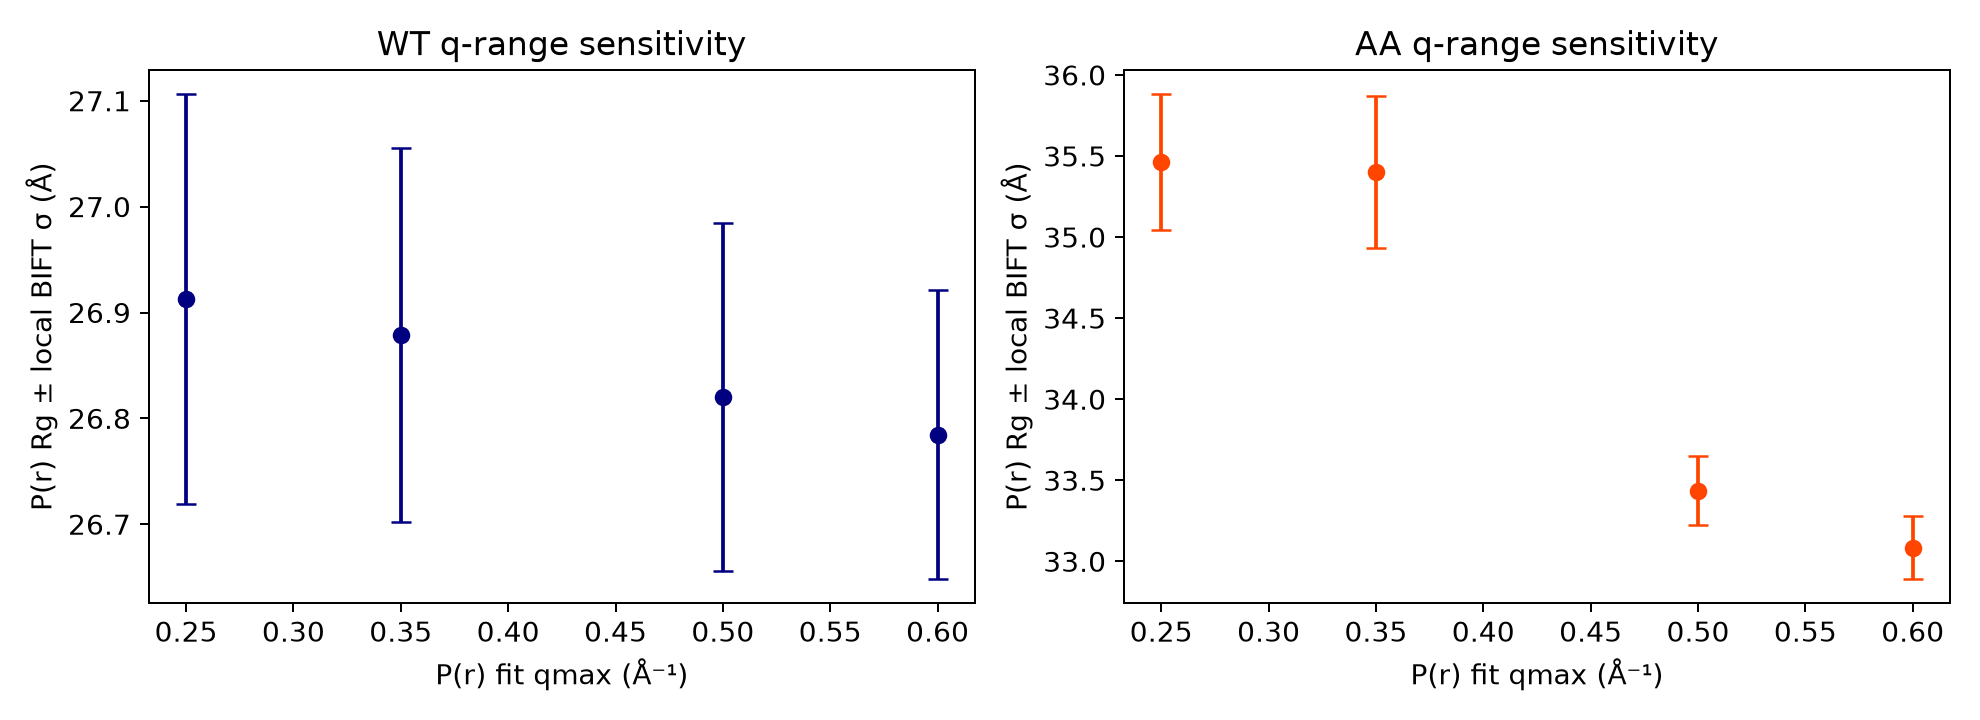

WT
qmax=0.25: Rg=26.91 ± 0.19 Å; Dmax=91.7 ± 3.6 Å; χ²=0.88
qmax=0.35: Rg=26.88 ± 0.18 Å; Dmax=91.1 ± 3.4 Å; χ²=0.79
qmax=0.50: Rg=26.82 ± 0.16 Å; Dmax=90.0 ± 3.0 Å; χ²=0.70
qmax=0.60: Rg=26.78 ± 0.14 Å; Dmax=88.5 ± 2.6 Å; χ²=0.65
AA
qmax=0.25: Rg=35.46 ± 0.42 Å; Dmax=166.7 ± 7.2 Å; χ²=0.94
qmax=0.35: Rg=35.40 ± 0.47 Å; Dmax=165.4 ± 6.8 Å; χ²=0.78
qmax=0.50: Rg=33.44 ± 0.21 Å; Dmax=127.4 ± 5.2 Å; χ²=0.81
qmax=0.60: Rg=33.08 ± 0.19 Å; Dmax=118.3 ± 4.5 Å; χ²=0.80


In [4]:
display(Image(filename=str(STYLE/'Pr_qmax.png')))
for row in json.loads((STYLE/'uncertainty_and_qmax.json').read_text()):
    print(row['sample'][:2])
    for b in row['bift']:
        print(f"qmax={b['qmax']:.2f}: Rg={b['rg']:.2f} ± {b['rger']:.2f} Å; Dmax={b['dmax']:.1f} ± {b['dmaxer']:.1f} Å; χ²={b['chisq']:.2f}")


## 1. Source trace and window selection

Candidate windows contain the main apex, span7–21frames, and are tested over q=0.012–0.15Å⁻¹. Their first and second halves are compared after fitting a multiplicative concentration scale, with shared-buffer and overlapping-frame covariance retained. We require mean squared standardized difference≤1.5 under early25–35, early60–70, early24–70, post220–236, and linear24–70→220–236 backgrounds, then maximize signal-to-noise within eligible windows.

WT additionally requires≤5% **window-integrated absolute contribution** from the other component in each of three nominal EFA models (early24–70/post220–236/linear). This is a descriptive model threshold, not a measured oligomer fraction; supports and baseline remain uncertain. AA is screened by measured curve consistency because its second component is not supported by the noise control. We do not use AA's unstable component as a purity gate. The search is bounded, so “selected” does not mean globally optimal.

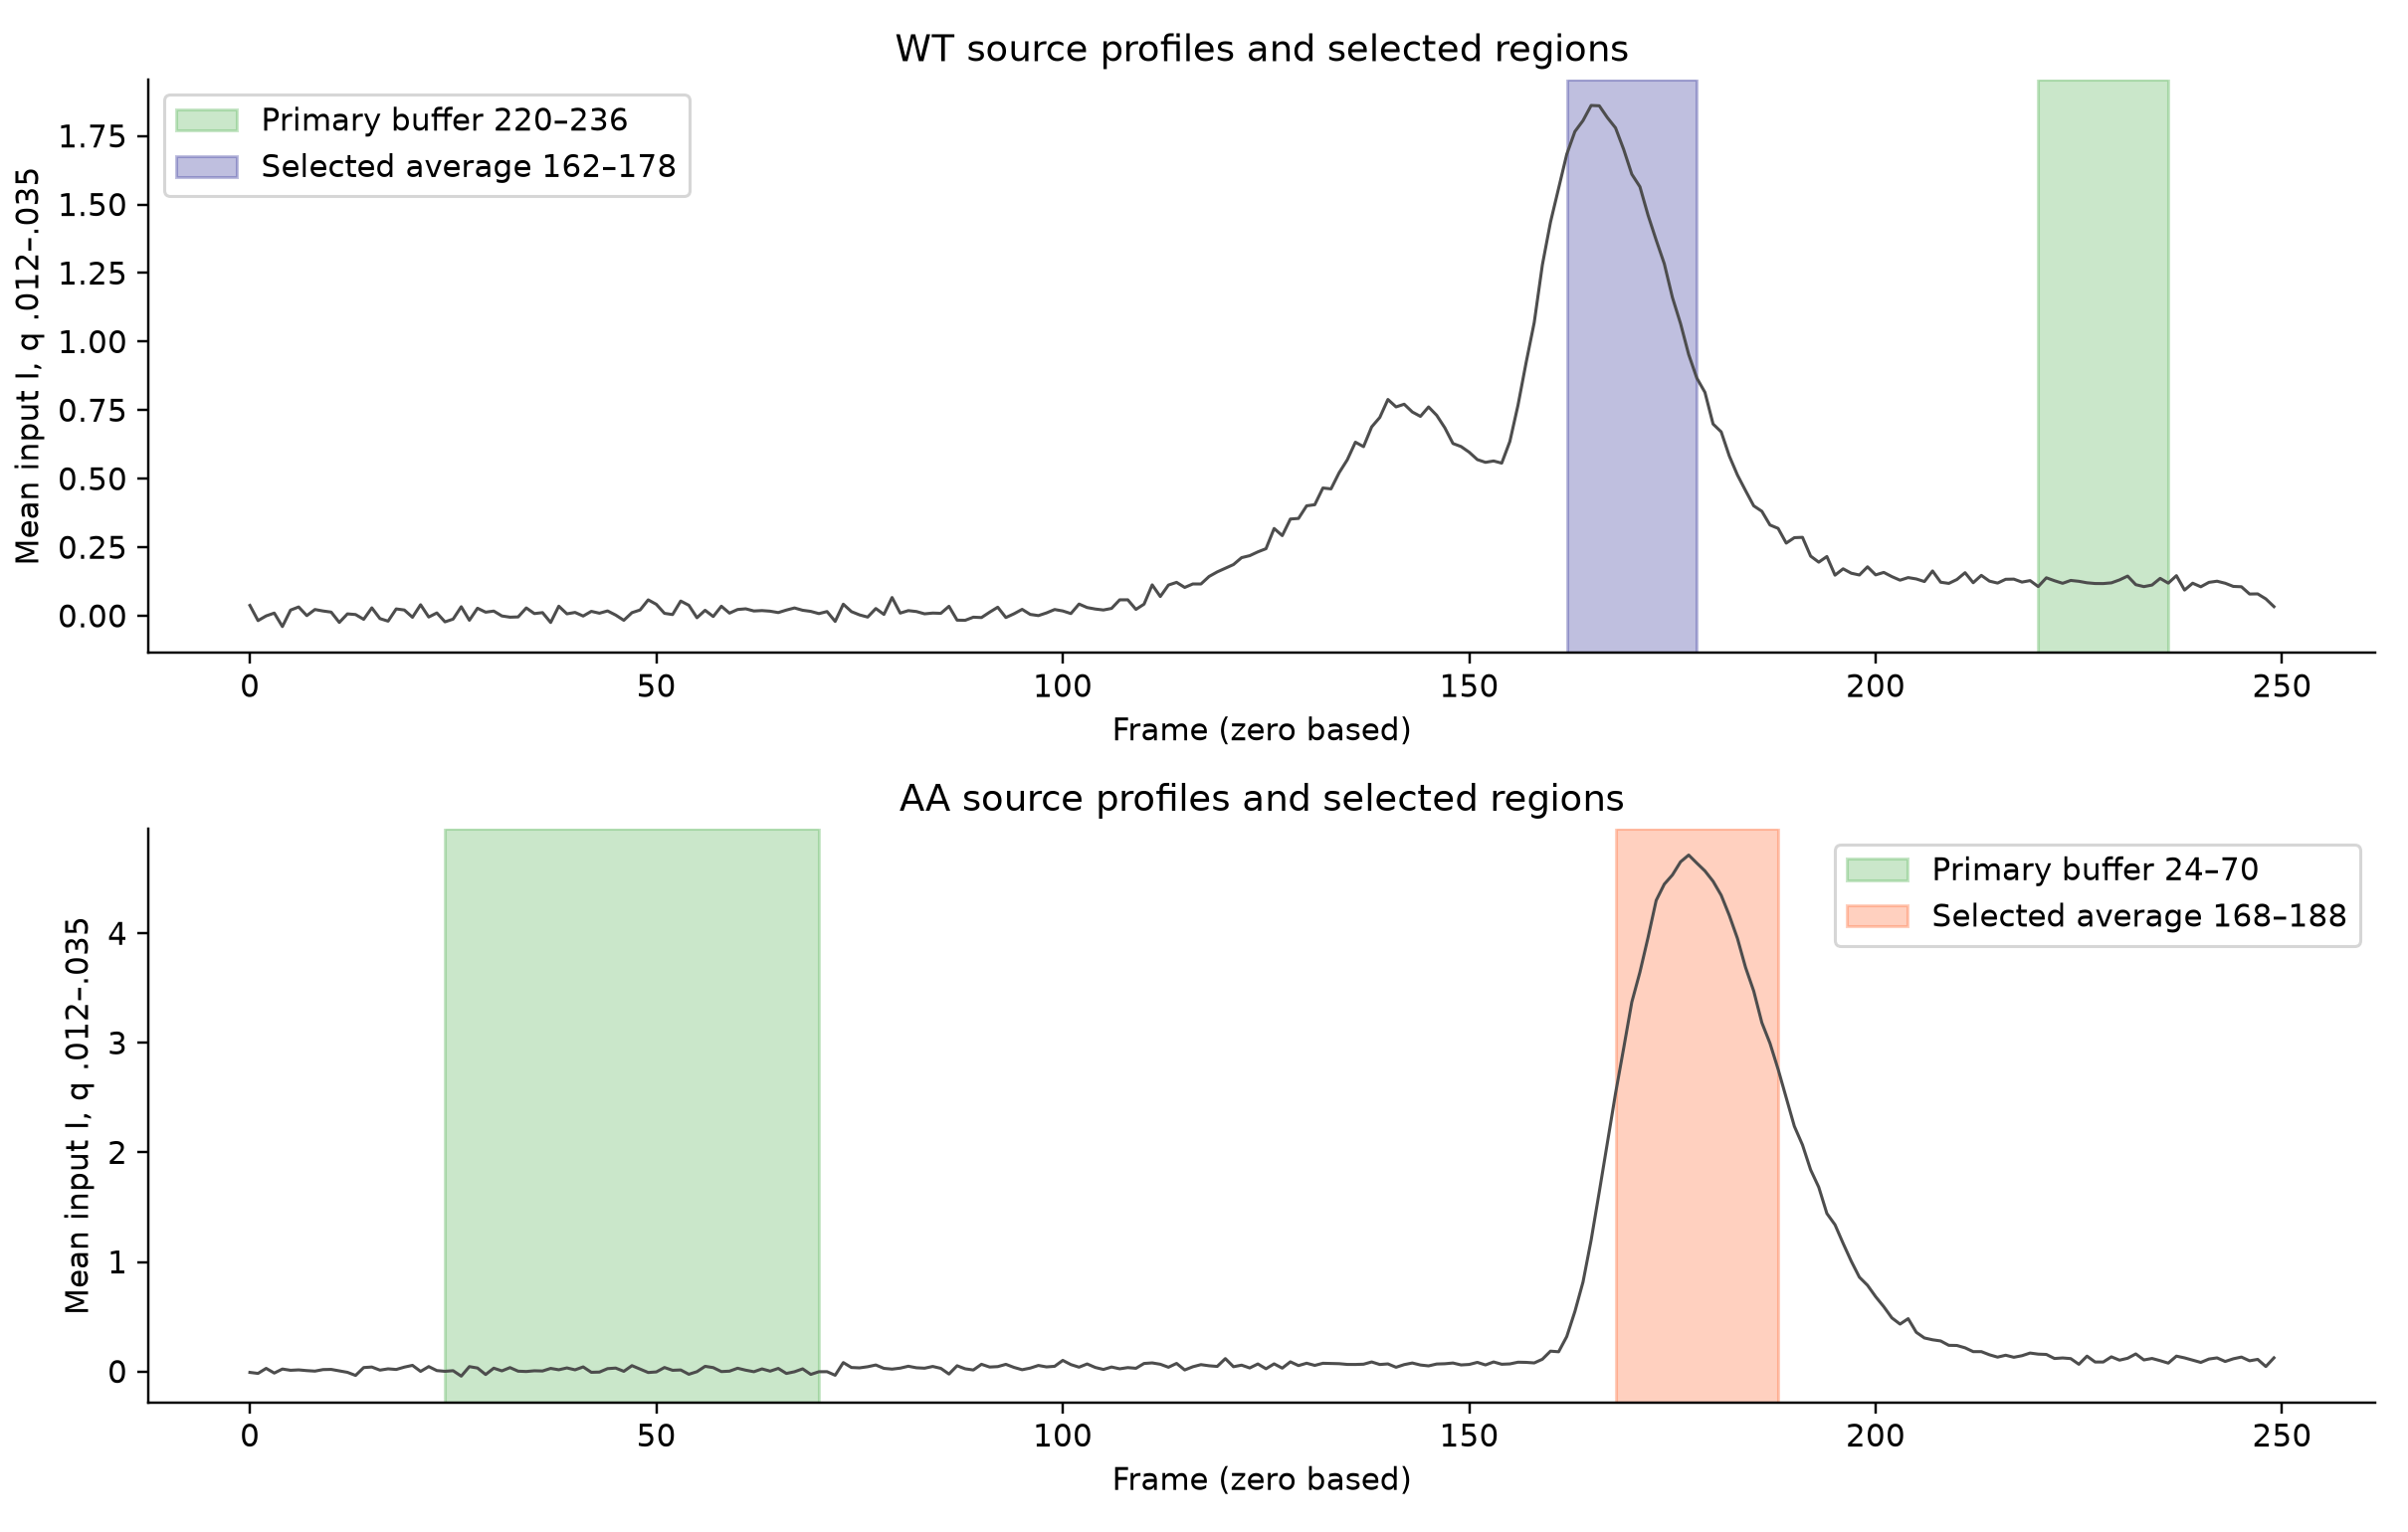

**WT:** buffer[220, 236]; average[162, 178]; halves metric0.885; EFA bootstrap convergence100/100.

**AA:** buffer[24, 70]; average[168, 188]; halves metric0.588; EFA bootstrap convergence100/100.

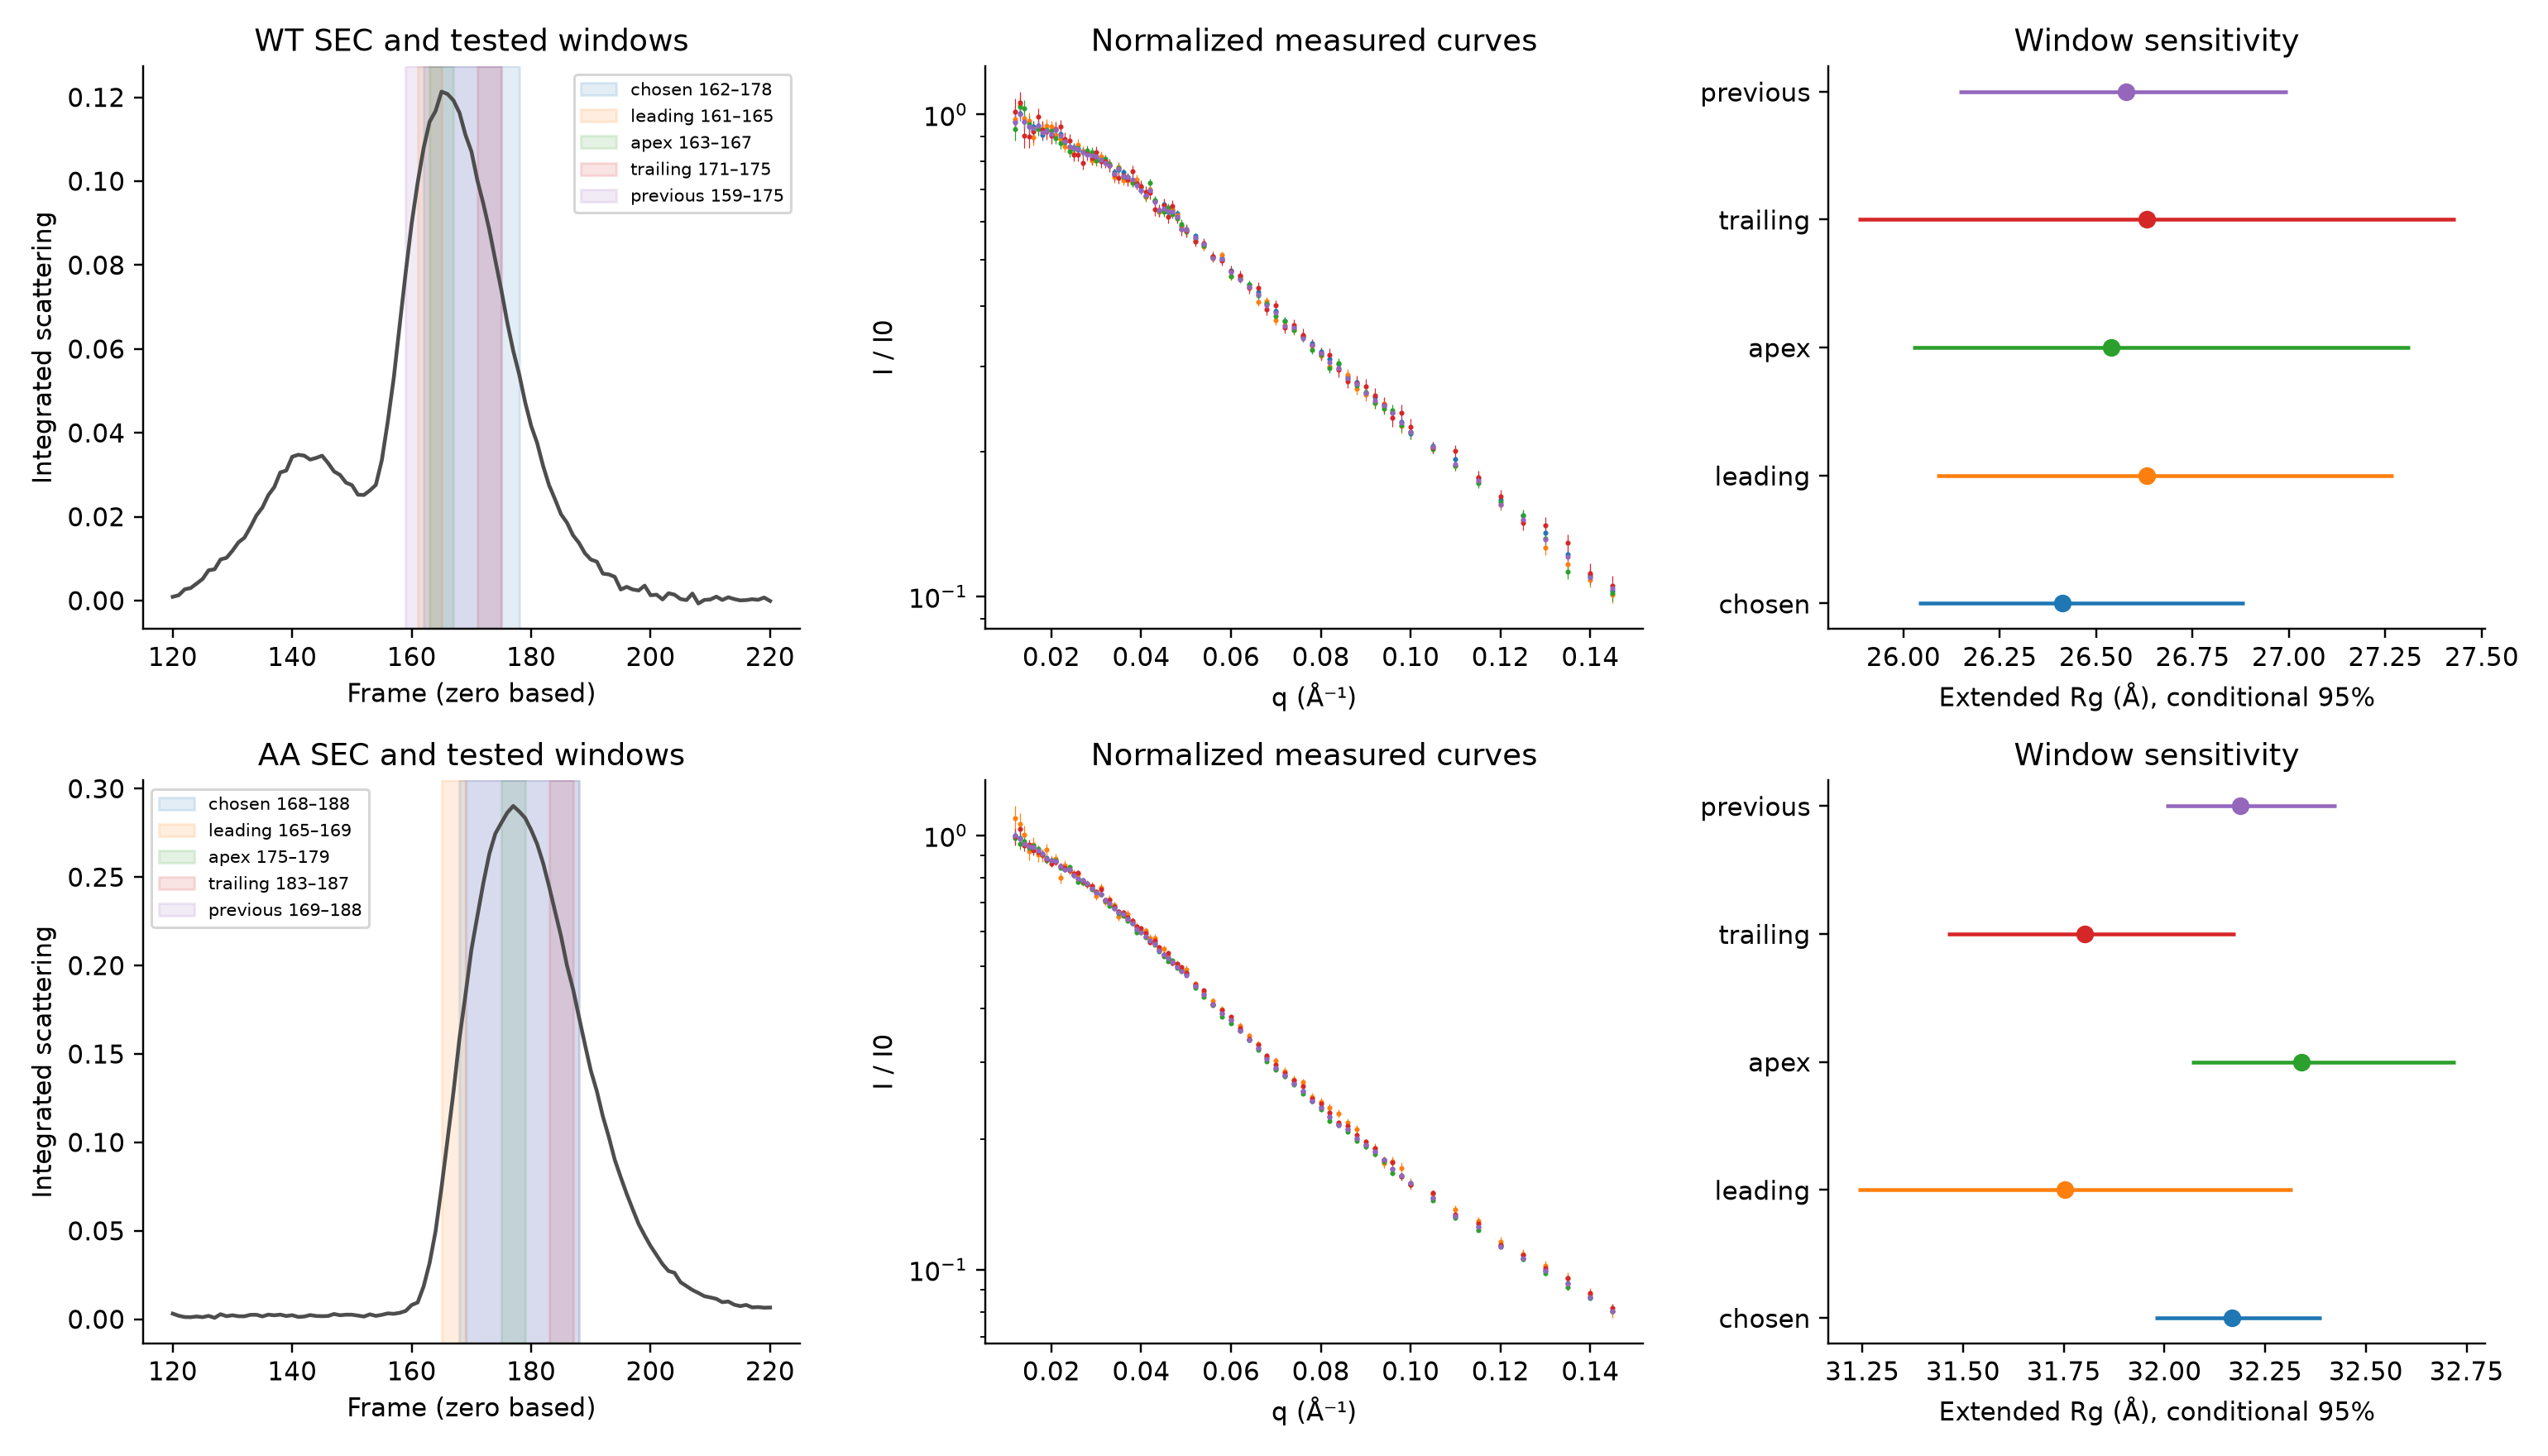

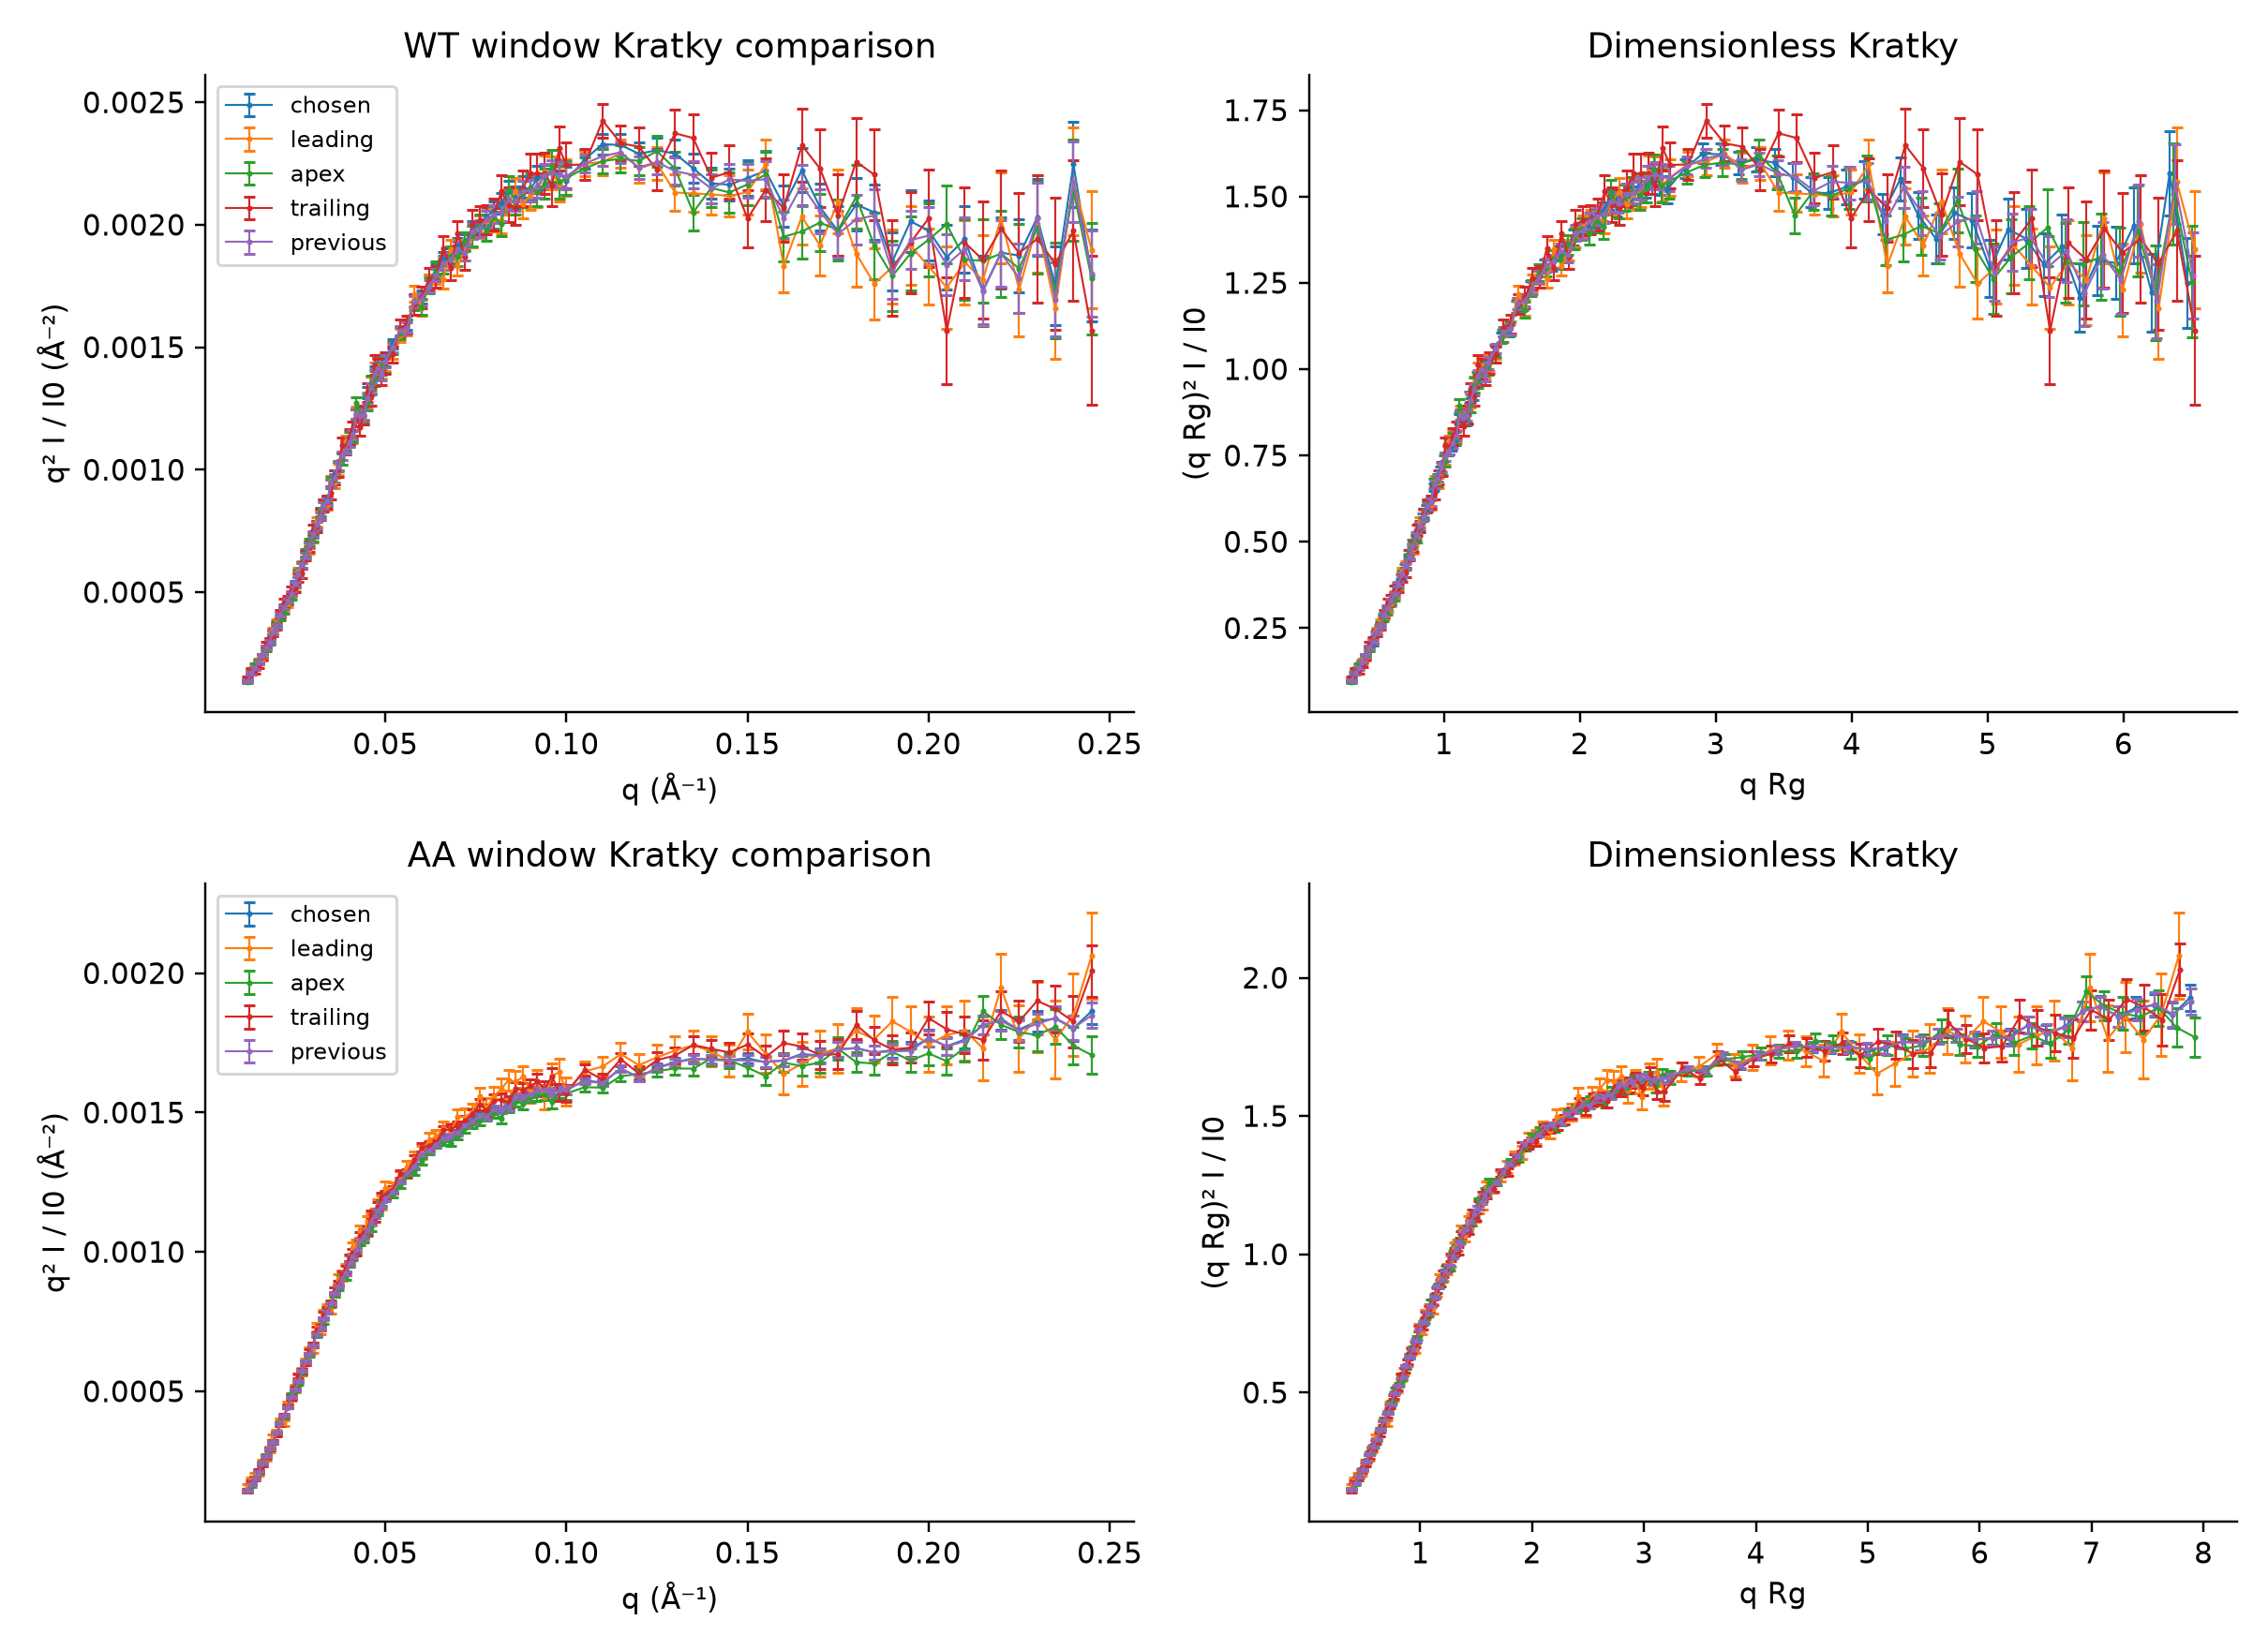

In [5]:
display(Image(filename=str(OUT/'06_buffer_and_SEC.png')))
for sample,c in choices.items():
    display(Markdown(f"**{sample[:2]}:** buffer{c['buffer']}; average{c['window']}; halves metric{c['selection']['max_halves_ms']:.3f}; EFA bootstrap convergence{c['efa_bootstrap_success']}/100."))
display(Image(filename=str(OUT/'02_window_selection.png')))
display(Image(filename=str(OUT/'08_window_Kratky.png')))


## 2. Primary WT–AA comparison

The same frame-average I(q) is used for every panel. Intensities are normalized only for shape comparison; no absolute molecular-weight inference is made. The conventional Guinier fit uses the widest allowed range beginning at0.012Å⁻¹ with qmaxRg≤1.1. The Zheng–Best extended fit uses a common0.012–0.055Å⁻¹ range, and requires qmaxRg≤2. The extended relation assumes120residues/119peptide bonds, matching the previous analysis; a118residue sensitivity check is below. This single-chain model is not used to identify the WT shoulder as a multimer.

Error bars propagate frame and shared-buffer errors. Shaded I(q)/Kratky bands are conditional95% intervals from100source-frame perturbations, refitting I(0) and Rg jointly; dimensionless bands are evaluated on a fixed qRg grid. They do not include biological replication, unknown q correlations, or uncertainty in which baseline is correct. P(r) shading is the BIFT local error at fixed plotted area normalization, not a total uncertainty band.

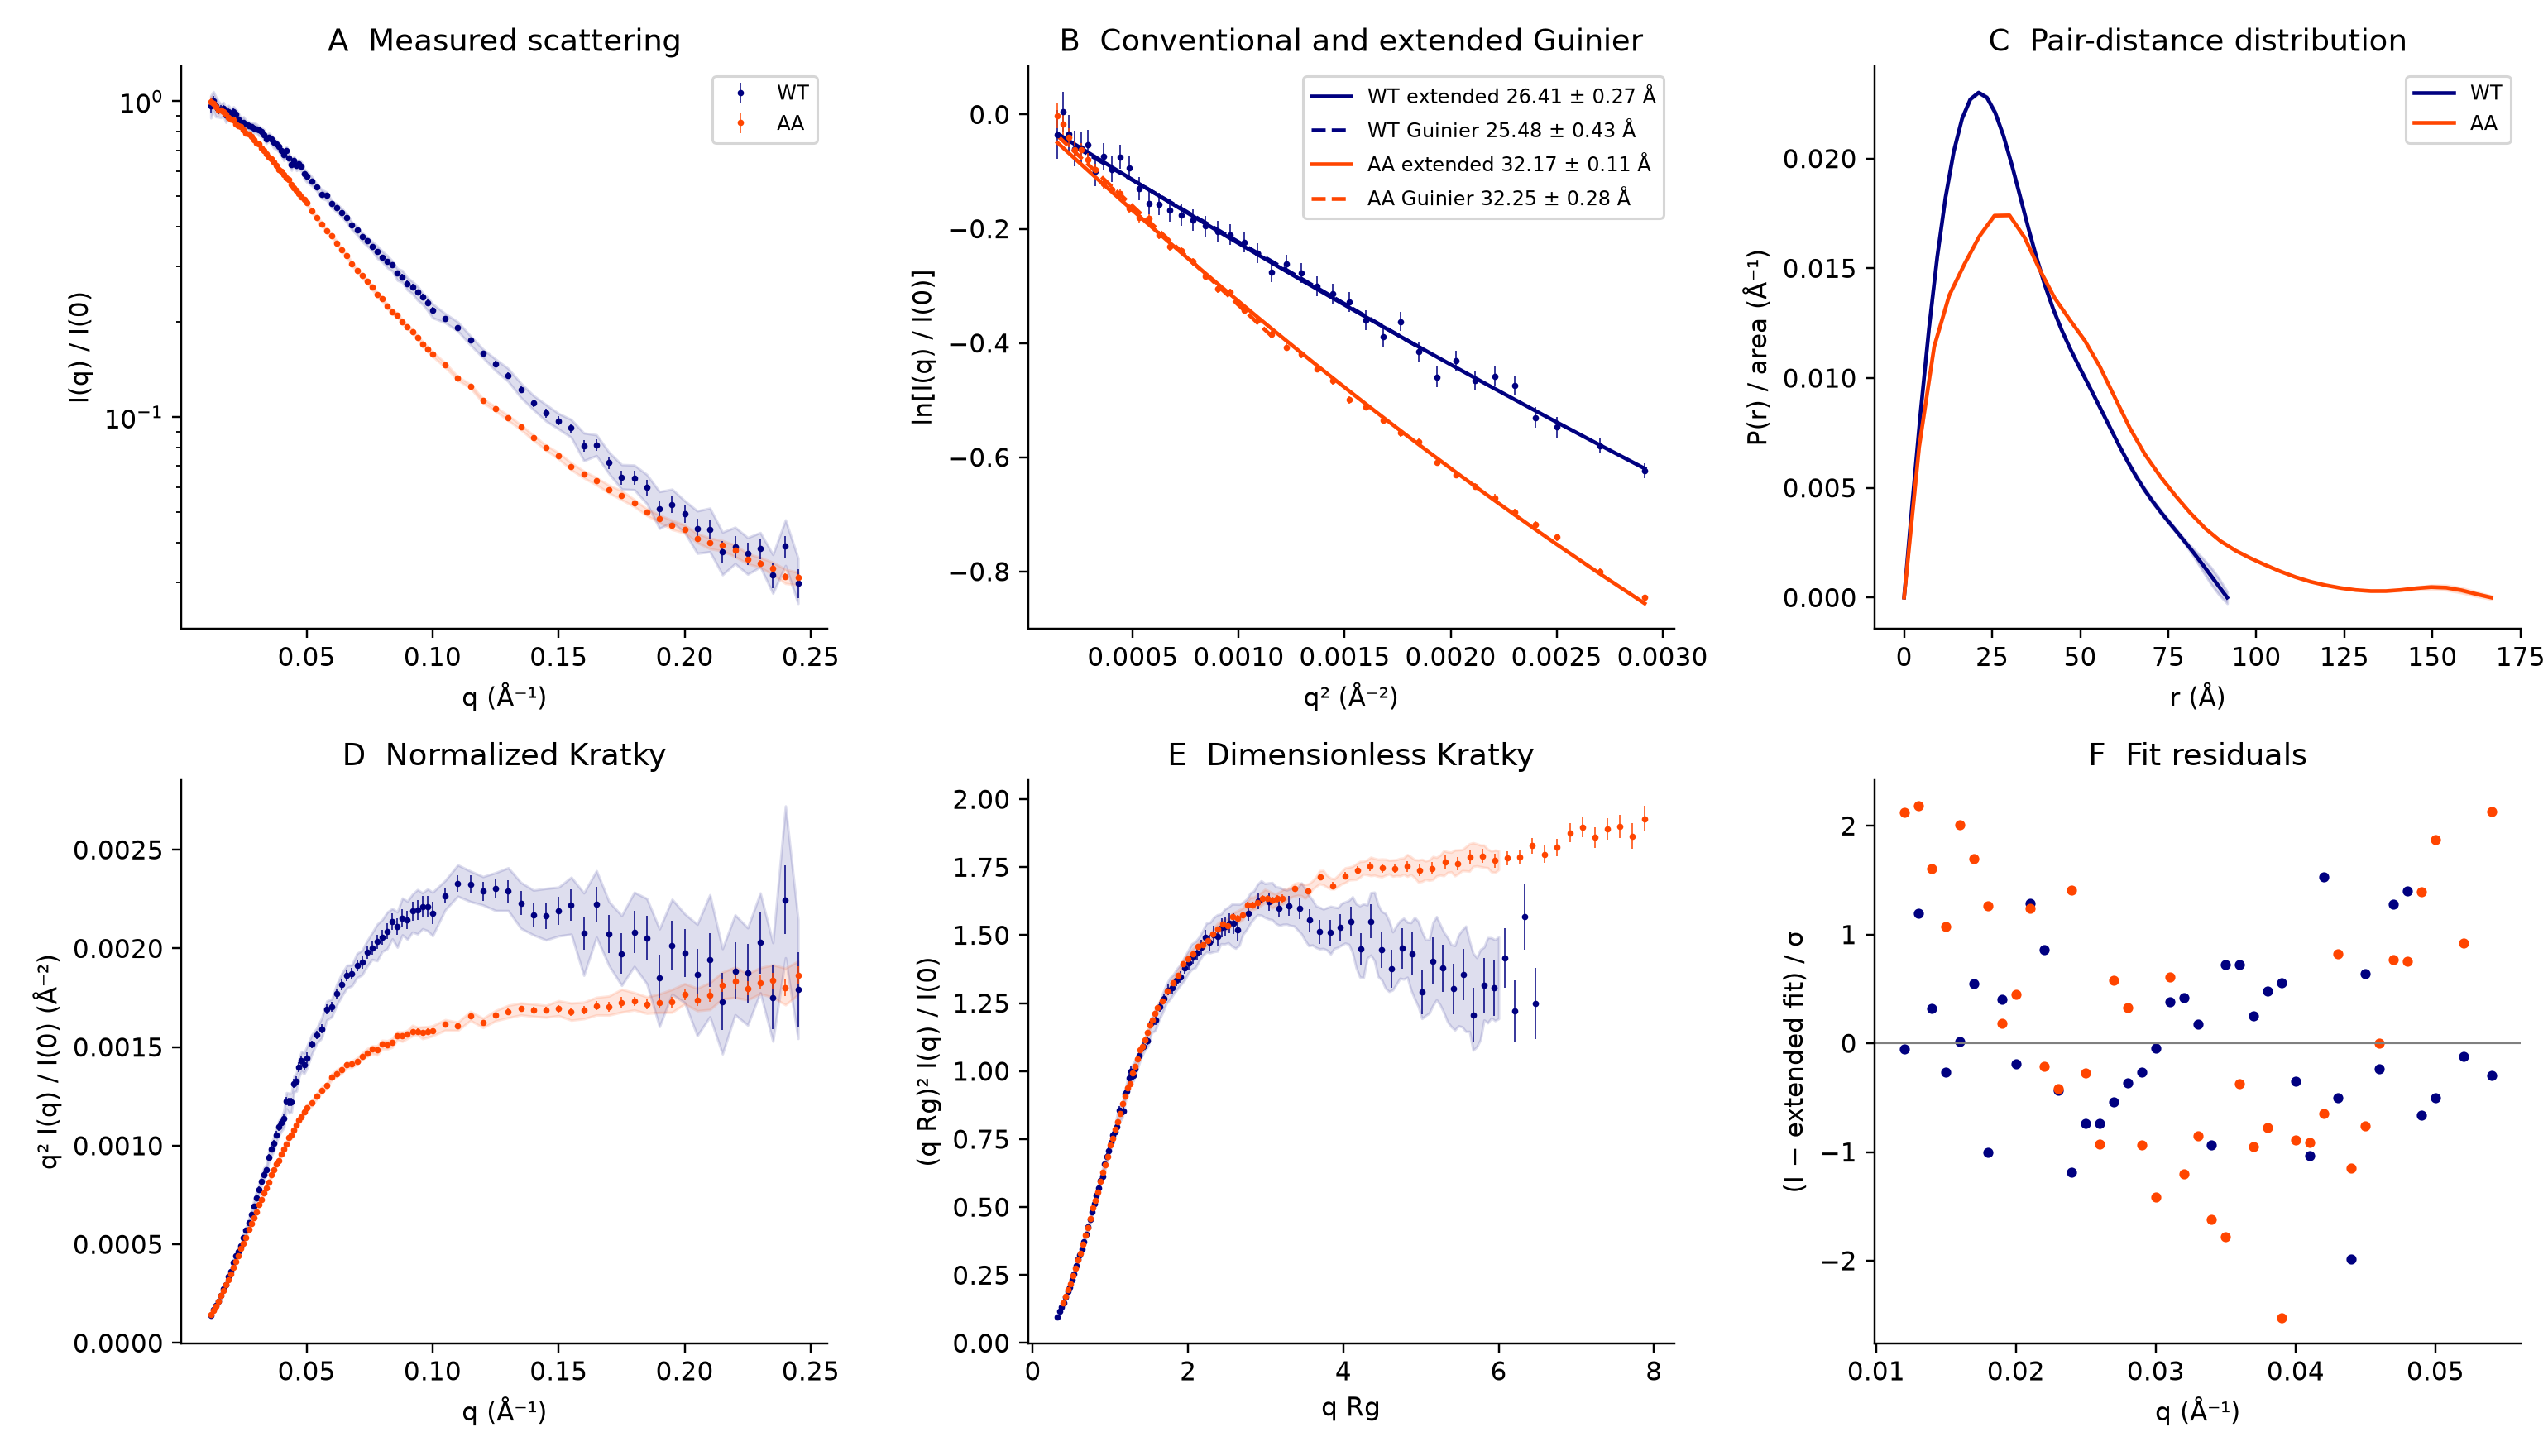

|Sample|Guinier Rg ± fit SE|Extended Rg ± fit SE|Extended bootstrap95%|P(r) Rg ± local BIFT σ|Dmax ± local BIFT σ|
|---|---:|---:|---|---:|---:|
|WT|25.48 ± 0.43|26.41 ± 0.27|[26.04, 26.89]|26.91 ± 0.19|91.7 ± 3.6|
|AA|32.25 ± 0.28|32.17 ± 0.11|[31.98, 32.39]|35.46 ± 0.42|166.7 ± 7.2|

All distances in Å. Local/conditional errors exclude baseline-model uncertainty.

WT 118-residue extended Rg: 26.423 Å
AA 118-residue extended Rg: 32.196 Å


In [6]:
display(Image(filename=str(OUT/'01_WT_AA_comparison.png')))
from natalie_style_figures import table
table()
from compare_all_iq import fit
for r in rows:
    if r['kind']=='chosen':
        q,y,e=np.loadtxt(OUT/(r['key']+'.dat')).T
        m=(q>=.012-1e-9)&(q<=.055+1e-9)
        f=fit(q[m],y[m],e[m],residues=118)
        print(r['sample'][:2], '118-residue extended Rg:',round(f['Rg'],3),'Å')


## 3. Does buffer subtraction help EFA?

Compare six background choices with identical nominal component supports and q=0.012–0.25Å⁻¹. `linear` directly interpolates between mean input profiles24–70 and220–236; it is not a second subtraction after buffer correction. For the rank-one controls, simulated noise is generated in source-frame space and transformed with exactly the same subtraction, preserving the correlation introduced by a shared buffer.

WT's second singular mode exceeds all60conditional rank-one noise controls under every tested baseline and has smooth q and time singular vectors. AA's second mode is below all60noise realizations under every tested baseline. This diagnostic is conditional on the supplied errors and the fitted rank-one model; it is not a formal species-count probability.

WT post-buffer subtraction improves the nominal two-component residual metric compared with early subtraction. AA's constrained second component changes sign, depends on baseline, and fails nominal rotation for60–70. A converged AA rotation—even100/100bootstrap convergence for the reference buffer—does not rescue a second pattern unsupported by the rank/noise diagnostic. **Use the direct AA average for the primary comparison, not a claimed purified AA EFA profile.**

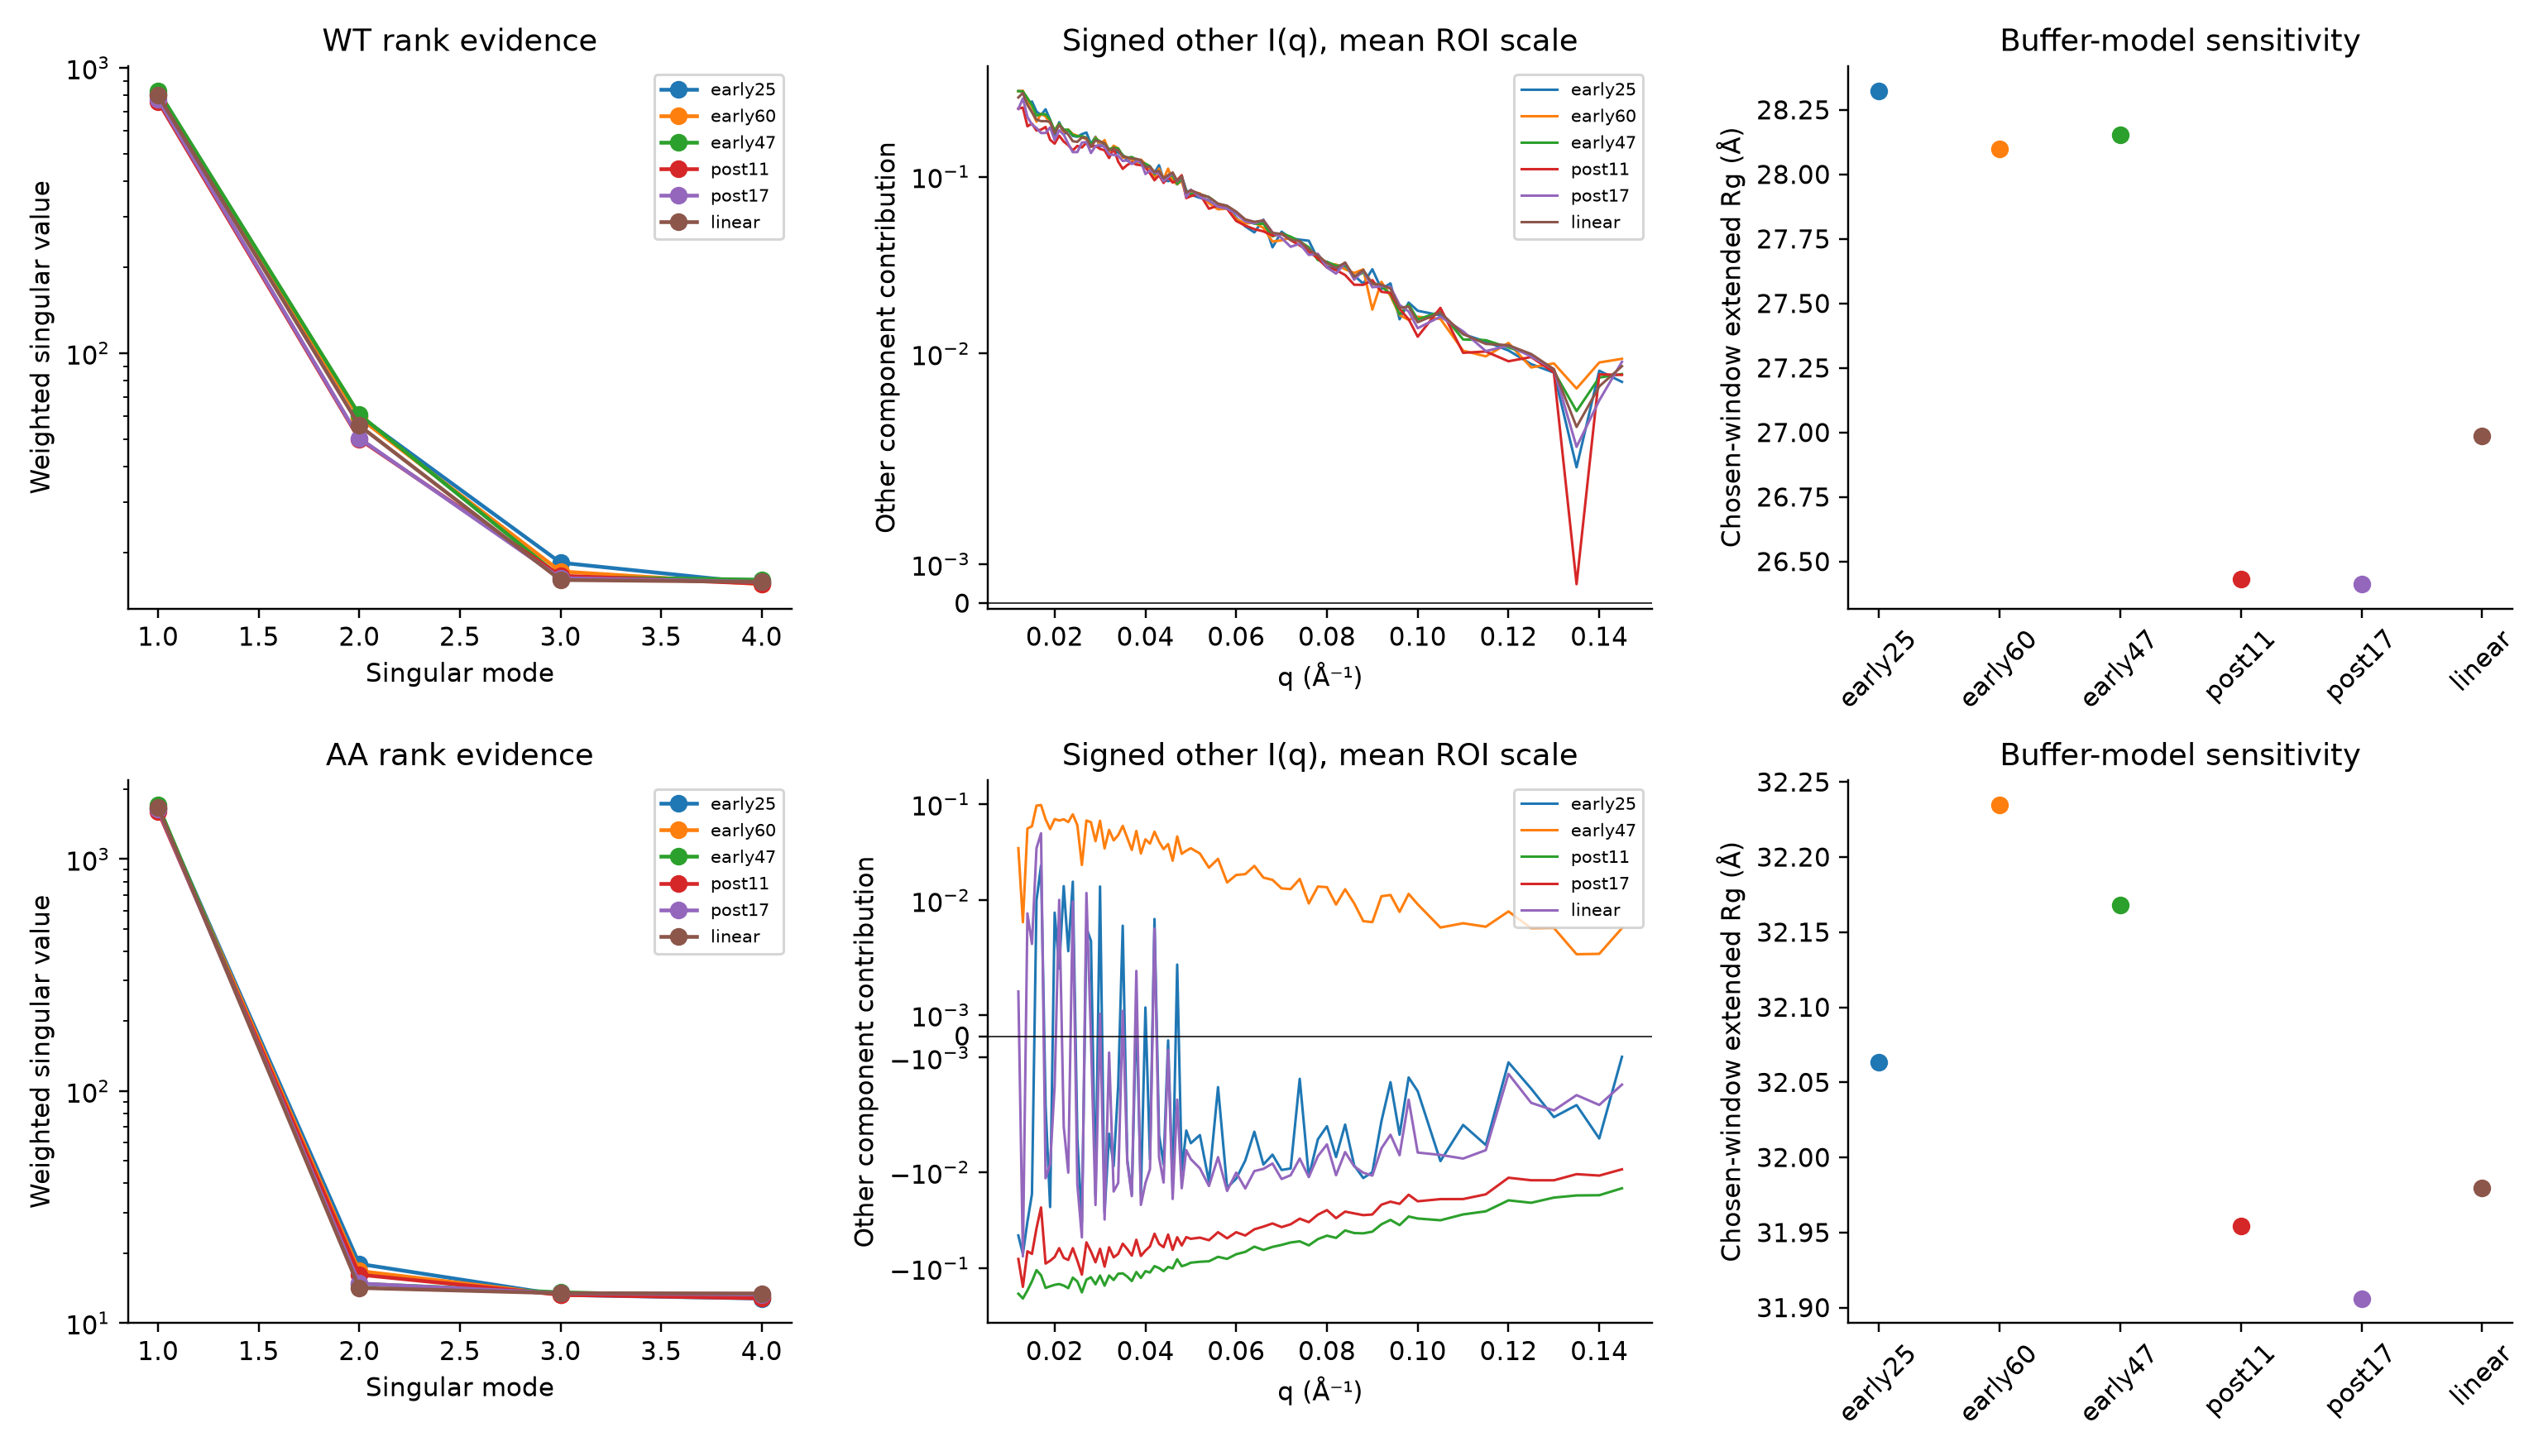

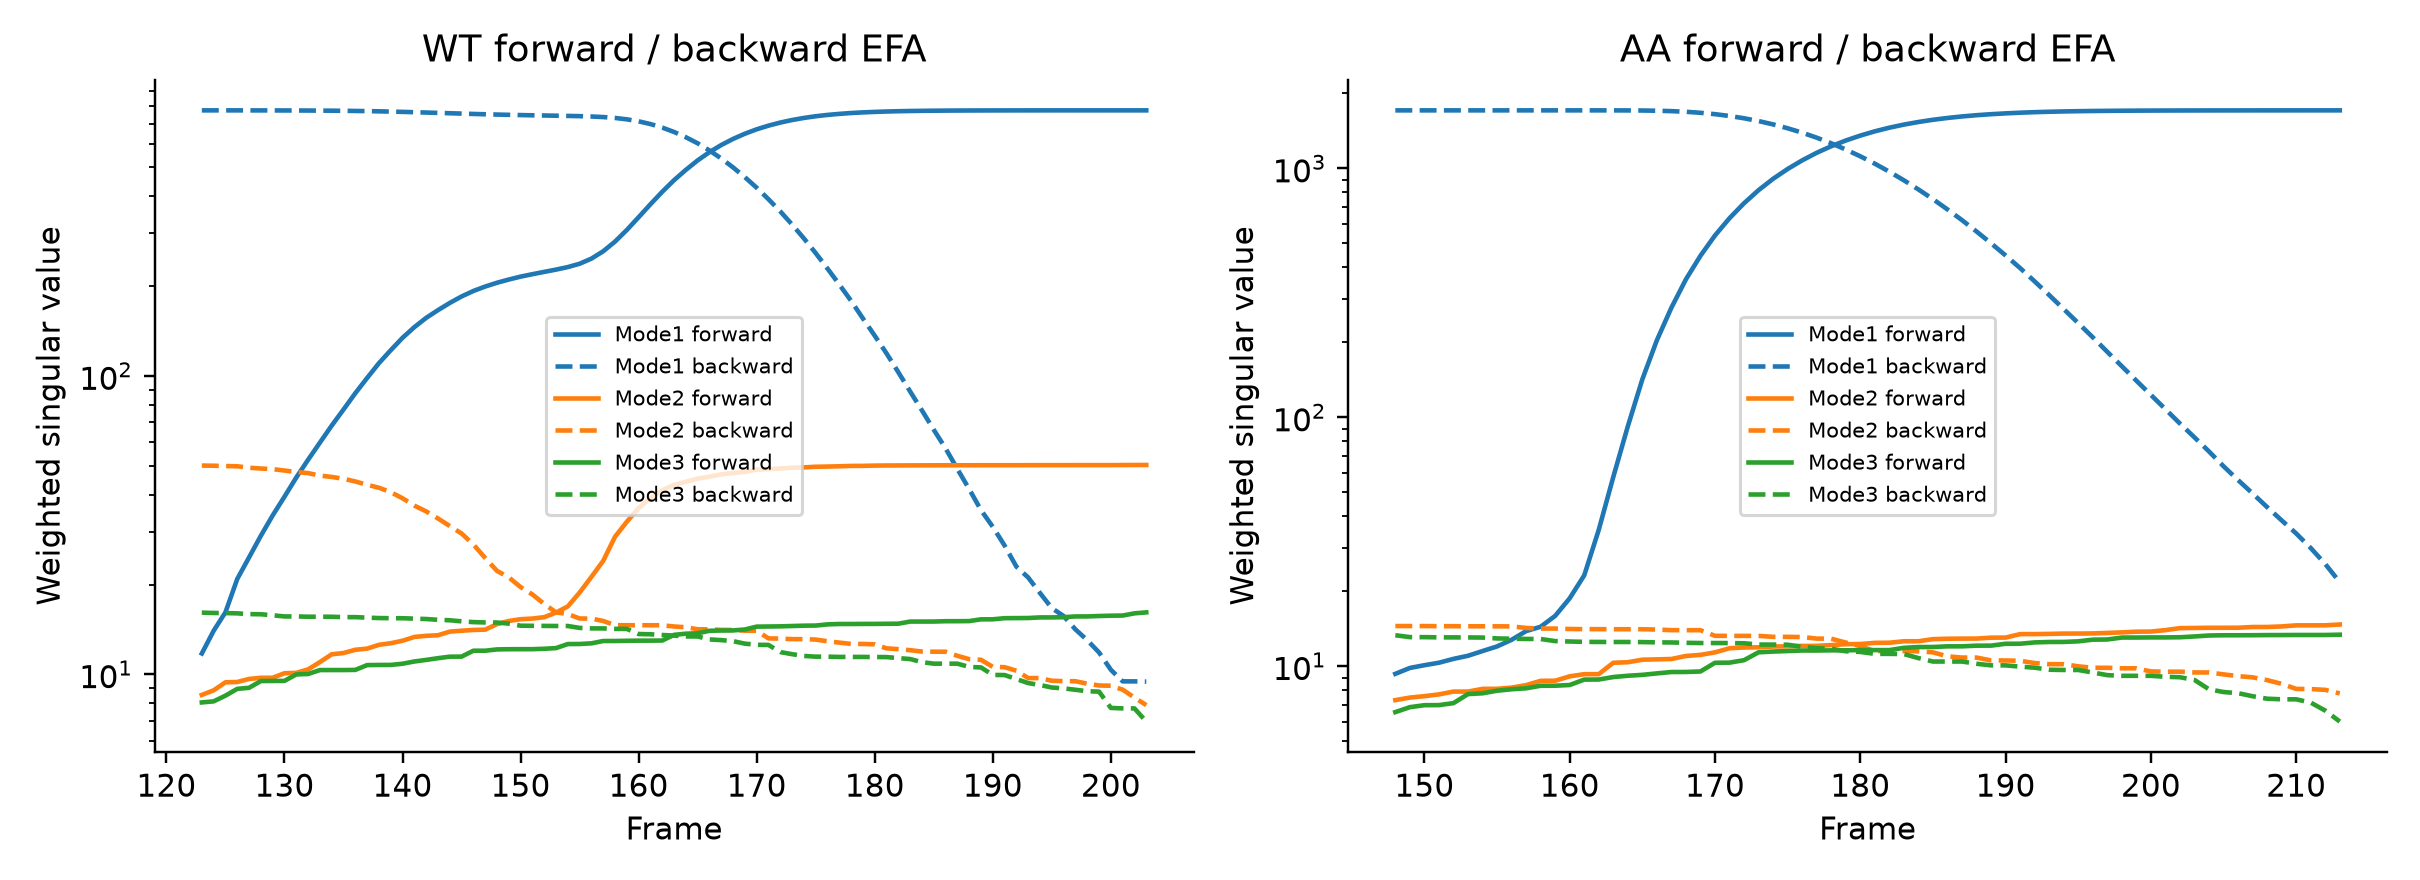

|Sample|Background|Converged|Rank1 residual MS|EFA residual MS|Mode2 q autocorrelation|Observed s2 / noise95|
|---|---|---|---:|---:|---:|---:|
|WT|early25|True|1.147|1.115|0.924|60.3/22.8|
|WT|early60|True|1.125|1.056|0.938|59.4/23.1|
|WT|early47|True|1.189|1.110|0.961|60.9/18.9|
|WT|post11|True|0.995|0.825|0.919|49.9/23.8|
|WT|post17|True|1.014|0.835|0.932|50.3/21.7|
|WT|linear|True|1.107|0.882|0.955|55.7/19.5|
|AA|early25|True|0.582|0.592|0.072|18.0/23.0|
|AA|early60|False|—|—|0.123|16.8/22.8|
|AA|early47|True|0.593|0.633|0.153|14.8/18.5|
|AA|post11|True|0.573|1.173|0.008|16.2/22.0|
|AA|post17|True|0.577|0.678|0.210|14.8/20.7|
|AA|linear|True|0.584|0.569|0.309|14.2/18.4|


In [7]:
display(Image(filename=str(OUT/'03_buffer_effect_on_EFA.png')))
display(Image(filename=str(OUT/'07_forward_backward_EFA.png')))
d=json.loads((OUT/'efa_diagnostics.json').read_text());noise=json.loads((OUT/'rank1_noise_controls.json').read_text())
h='|Sample|Background|Converged|Rank1 residual MS|EFA residual MS|Mode2 q autocorrelation|Observed s2 / noise95|\n|---|---|---|---:|---:|---:|---:|\n'
for r in d:
    z=next(z for z in noise if z['sample']==r['sample'] and z['model']==r['model'])
    fmt=lambda x:'—' if x is None else f'{x:.3f}'
    h+=f"|{r['sample'][:2]}|{r['model']}|{r['converged']}|{fmt(r.get('rank1_residual_ms'))}|{fmt(r.get('residual_ms'))}|{r['mode2_q_ac']:.3f}|{z['observed_s2']:.1f}/{z['rank1_noise_s2_95']:.1f}|\n"
display(Markdown(h))


## 4. Simplest defensible WT EFA result

Two components, shown as I(q) first, then their elution profiles. The primary supports are shoulder120–175 and main140–205; EFA uses0.012–0.25Å⁻¹. Data below0.012Å⁻¹ in panelA are extrapolated component estimates from the fitted elution coefficients, not points used in the decomposition. In panelB each elution profile has its own maximum normalization: heights are not concentrations or oligomer fractions. Exact zeros at support boundaries are imposed by the model.

The shoulder is a reproducible, largely positive, decaying scattering pattern that also resembles the direct shoulder average. **It is not just random noise.** Its low-q behavior and uncertainty still do not yield a supported conventional Guinier fit under the stated criteria; the single-chain extended fit is unsupported. Label it “early-eluting shoulder component” or “putative higher-size component,” not a resolved dimer/multimer of known Rg. An earlier SEC elution position and steeper curve are suggestive, not an oligomer assignment.

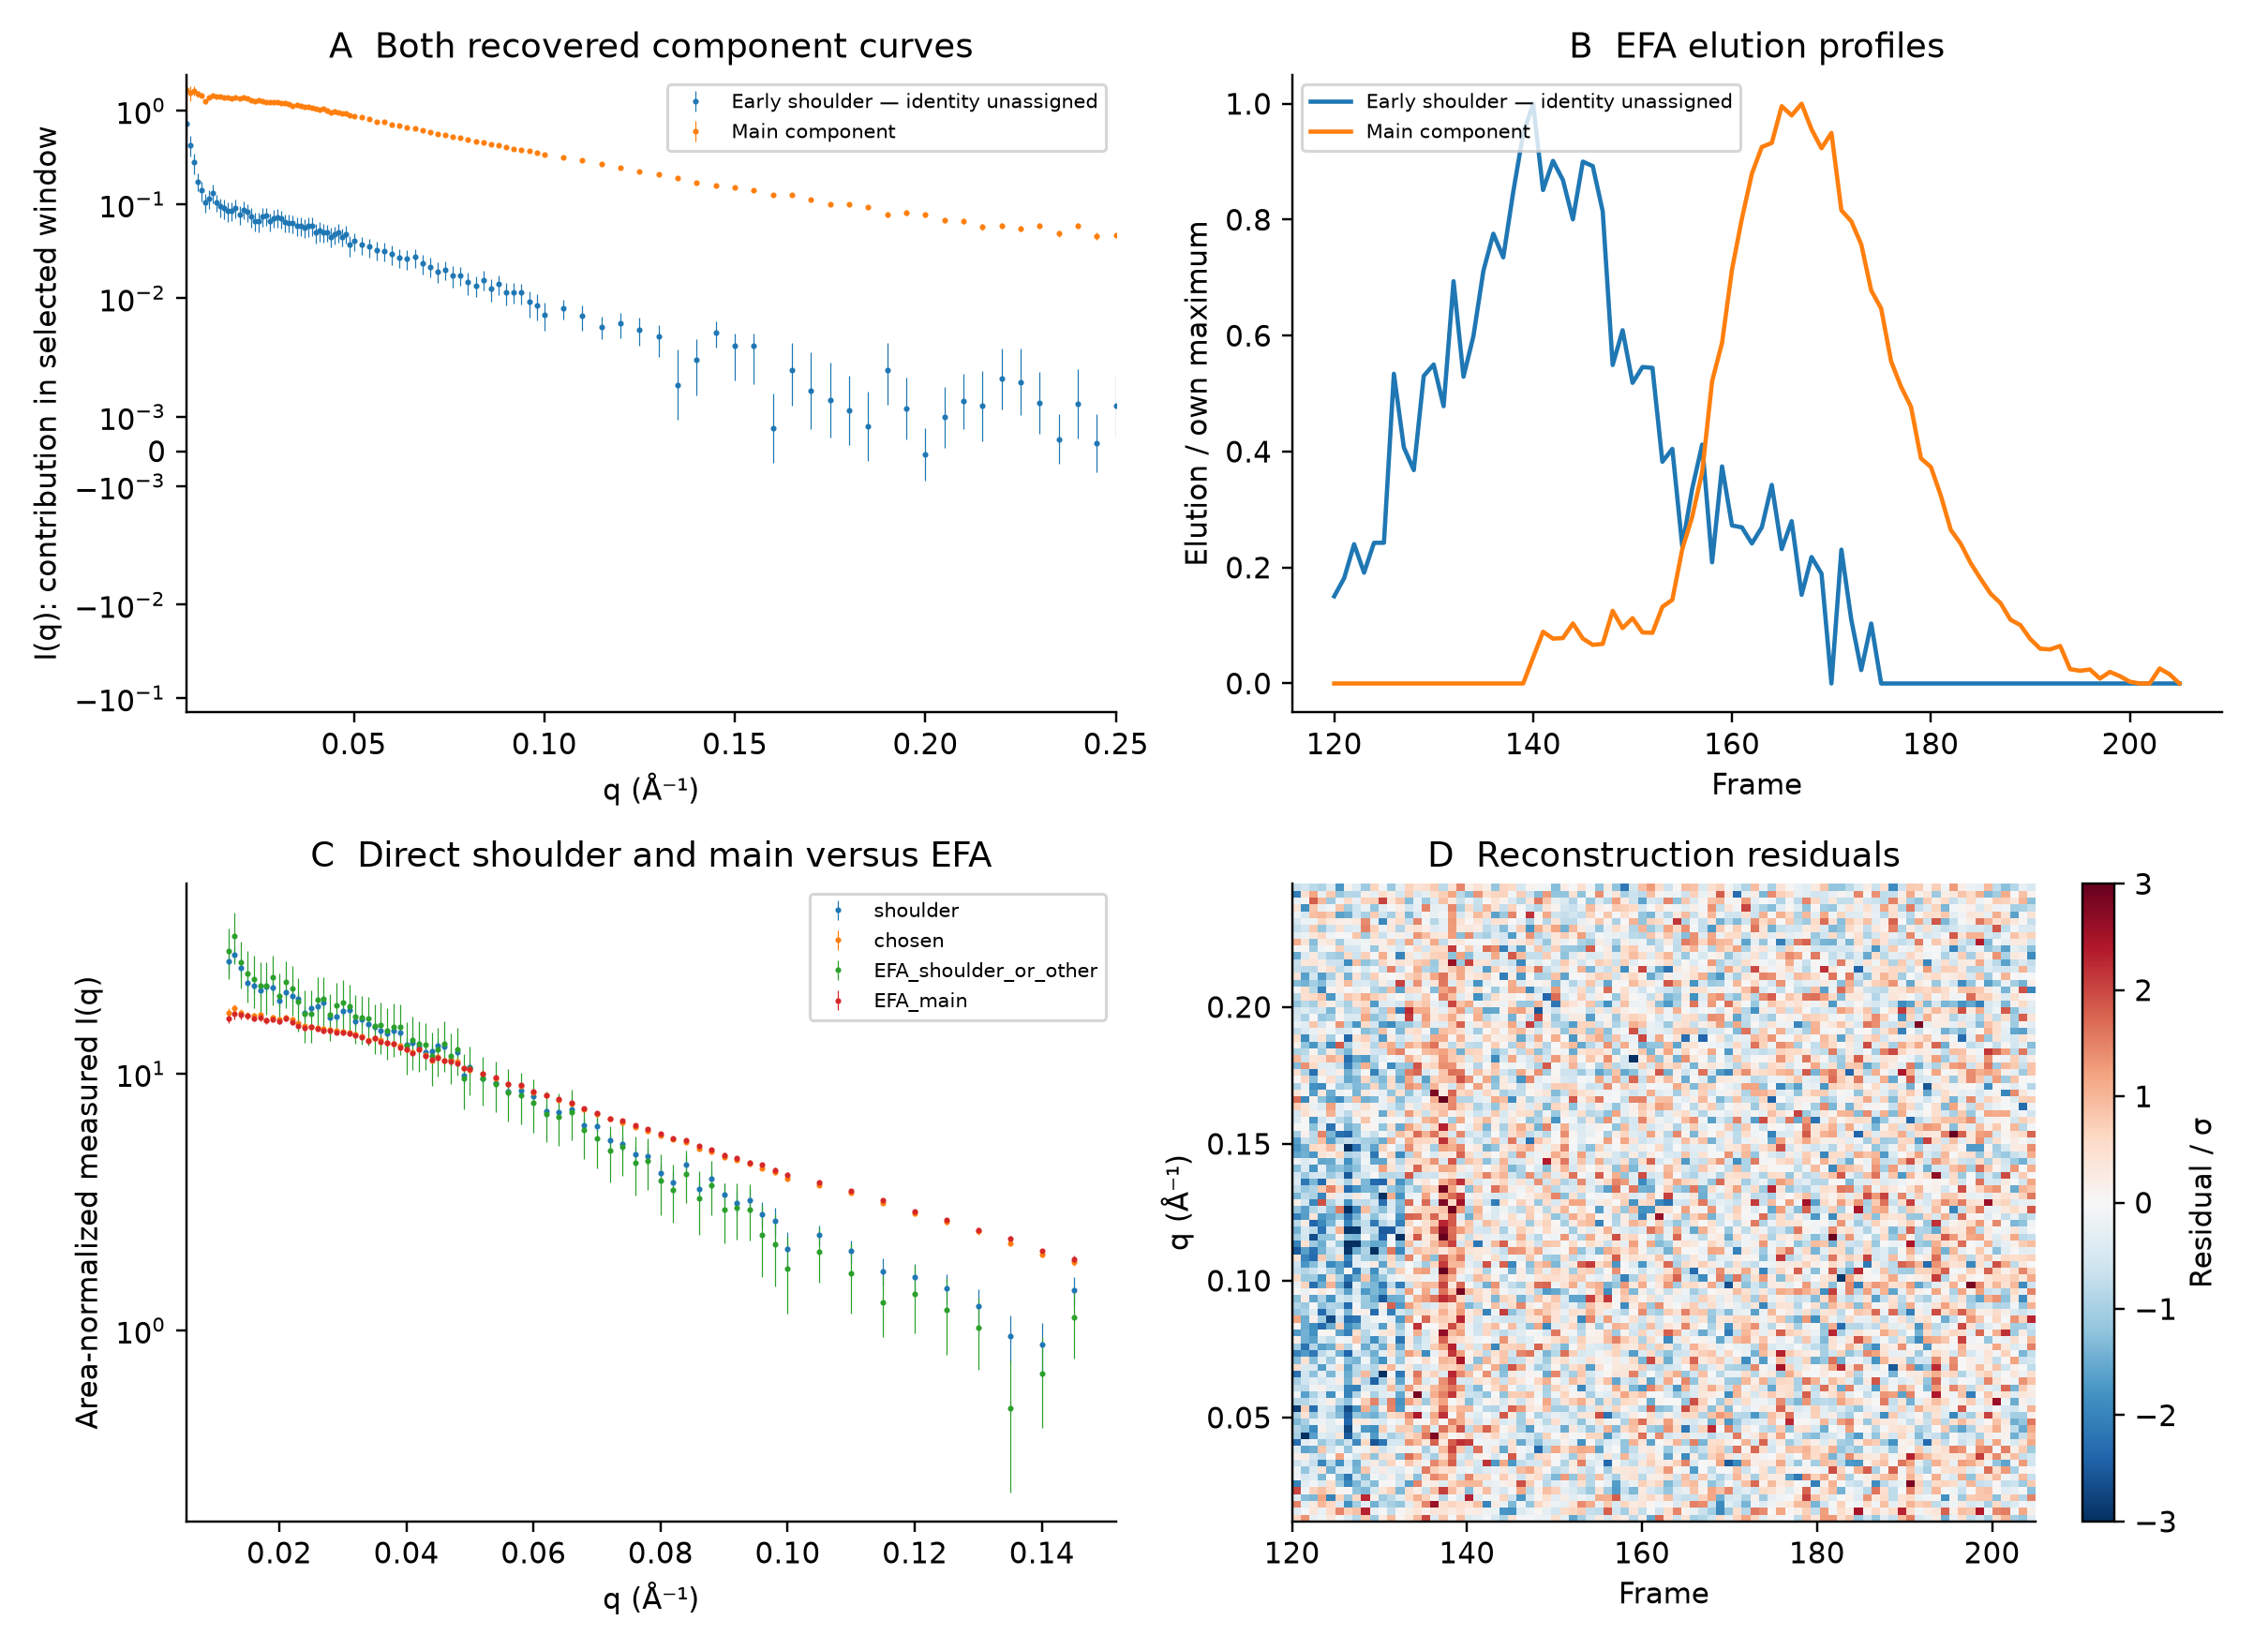

WT support/q-range rotations: 54 / 54 converged
  early47 conditional main Rg model range: [28.03, 35.75]
  post17 conditional main Rg model range: [25.64, 26.05]
  linear conditional main Rg model range: [26.27, 26.68]
AA support/q-range rotations: 50 / 54 converged
  early47 conditional main Rg model range: [31.86, 32.08]
  post17 conditional main Rg model range: [31.01, 31.86]
  linear conditional main Rg model range: [31.29, 31.85]


In [8]:
display(Image(filename=str(OUT/'04_WT_EFA.png')))
grid=json.loads((OUT/'support_grid.json').read_text())
for sample in choices:
    rr=[r for r in grid if r['sample']==sample];ok=[r for r in rr if r['converged']]
    print(sample[:2], 'support/q-range rotations:',len(ok),'/',len(rr),'converged')
    for model in ['early47','post17','linear']:
        vals=[r['main_fits']['extended']['Rg'] for r in ok if r['model']==model and r['main_fits']['extended']]
        print(' ',model,'conditional main Rg model range:',[round(min(vals),2),round(max(vals),2)] if vals else 'unsupported')


## 5. P(r) and baseline sensitivity must accompany the main figure

BIFT uses the same0.012–0.25Å⁻¹ range,40real-space points and regularization search for both proteins. The additional runs vary the **initial Dmax search upper limit** (160/220/280Å); RAW's final optimizer can move outside that initial grid. These are sensitivity checks, not hard Dmax constraints.

WT's reference post-buffer P(r) is stable to the tested Dmax search initialization, and the interpolated baseline gives a nearby result. With the early24–70buffer, WT develops a long-distance tail and a much larger P(r)-derived Rg despite a much smaller change in Guinier Rg. AA's P(r) also changes with baseline. Do not conceal this by truncating the tail, forcing a Dmax, or selecting the visually smoothest curve. The primary P(r) panels are conditional on the stated reference processing; baseline uncertainty remains a publication limitation.

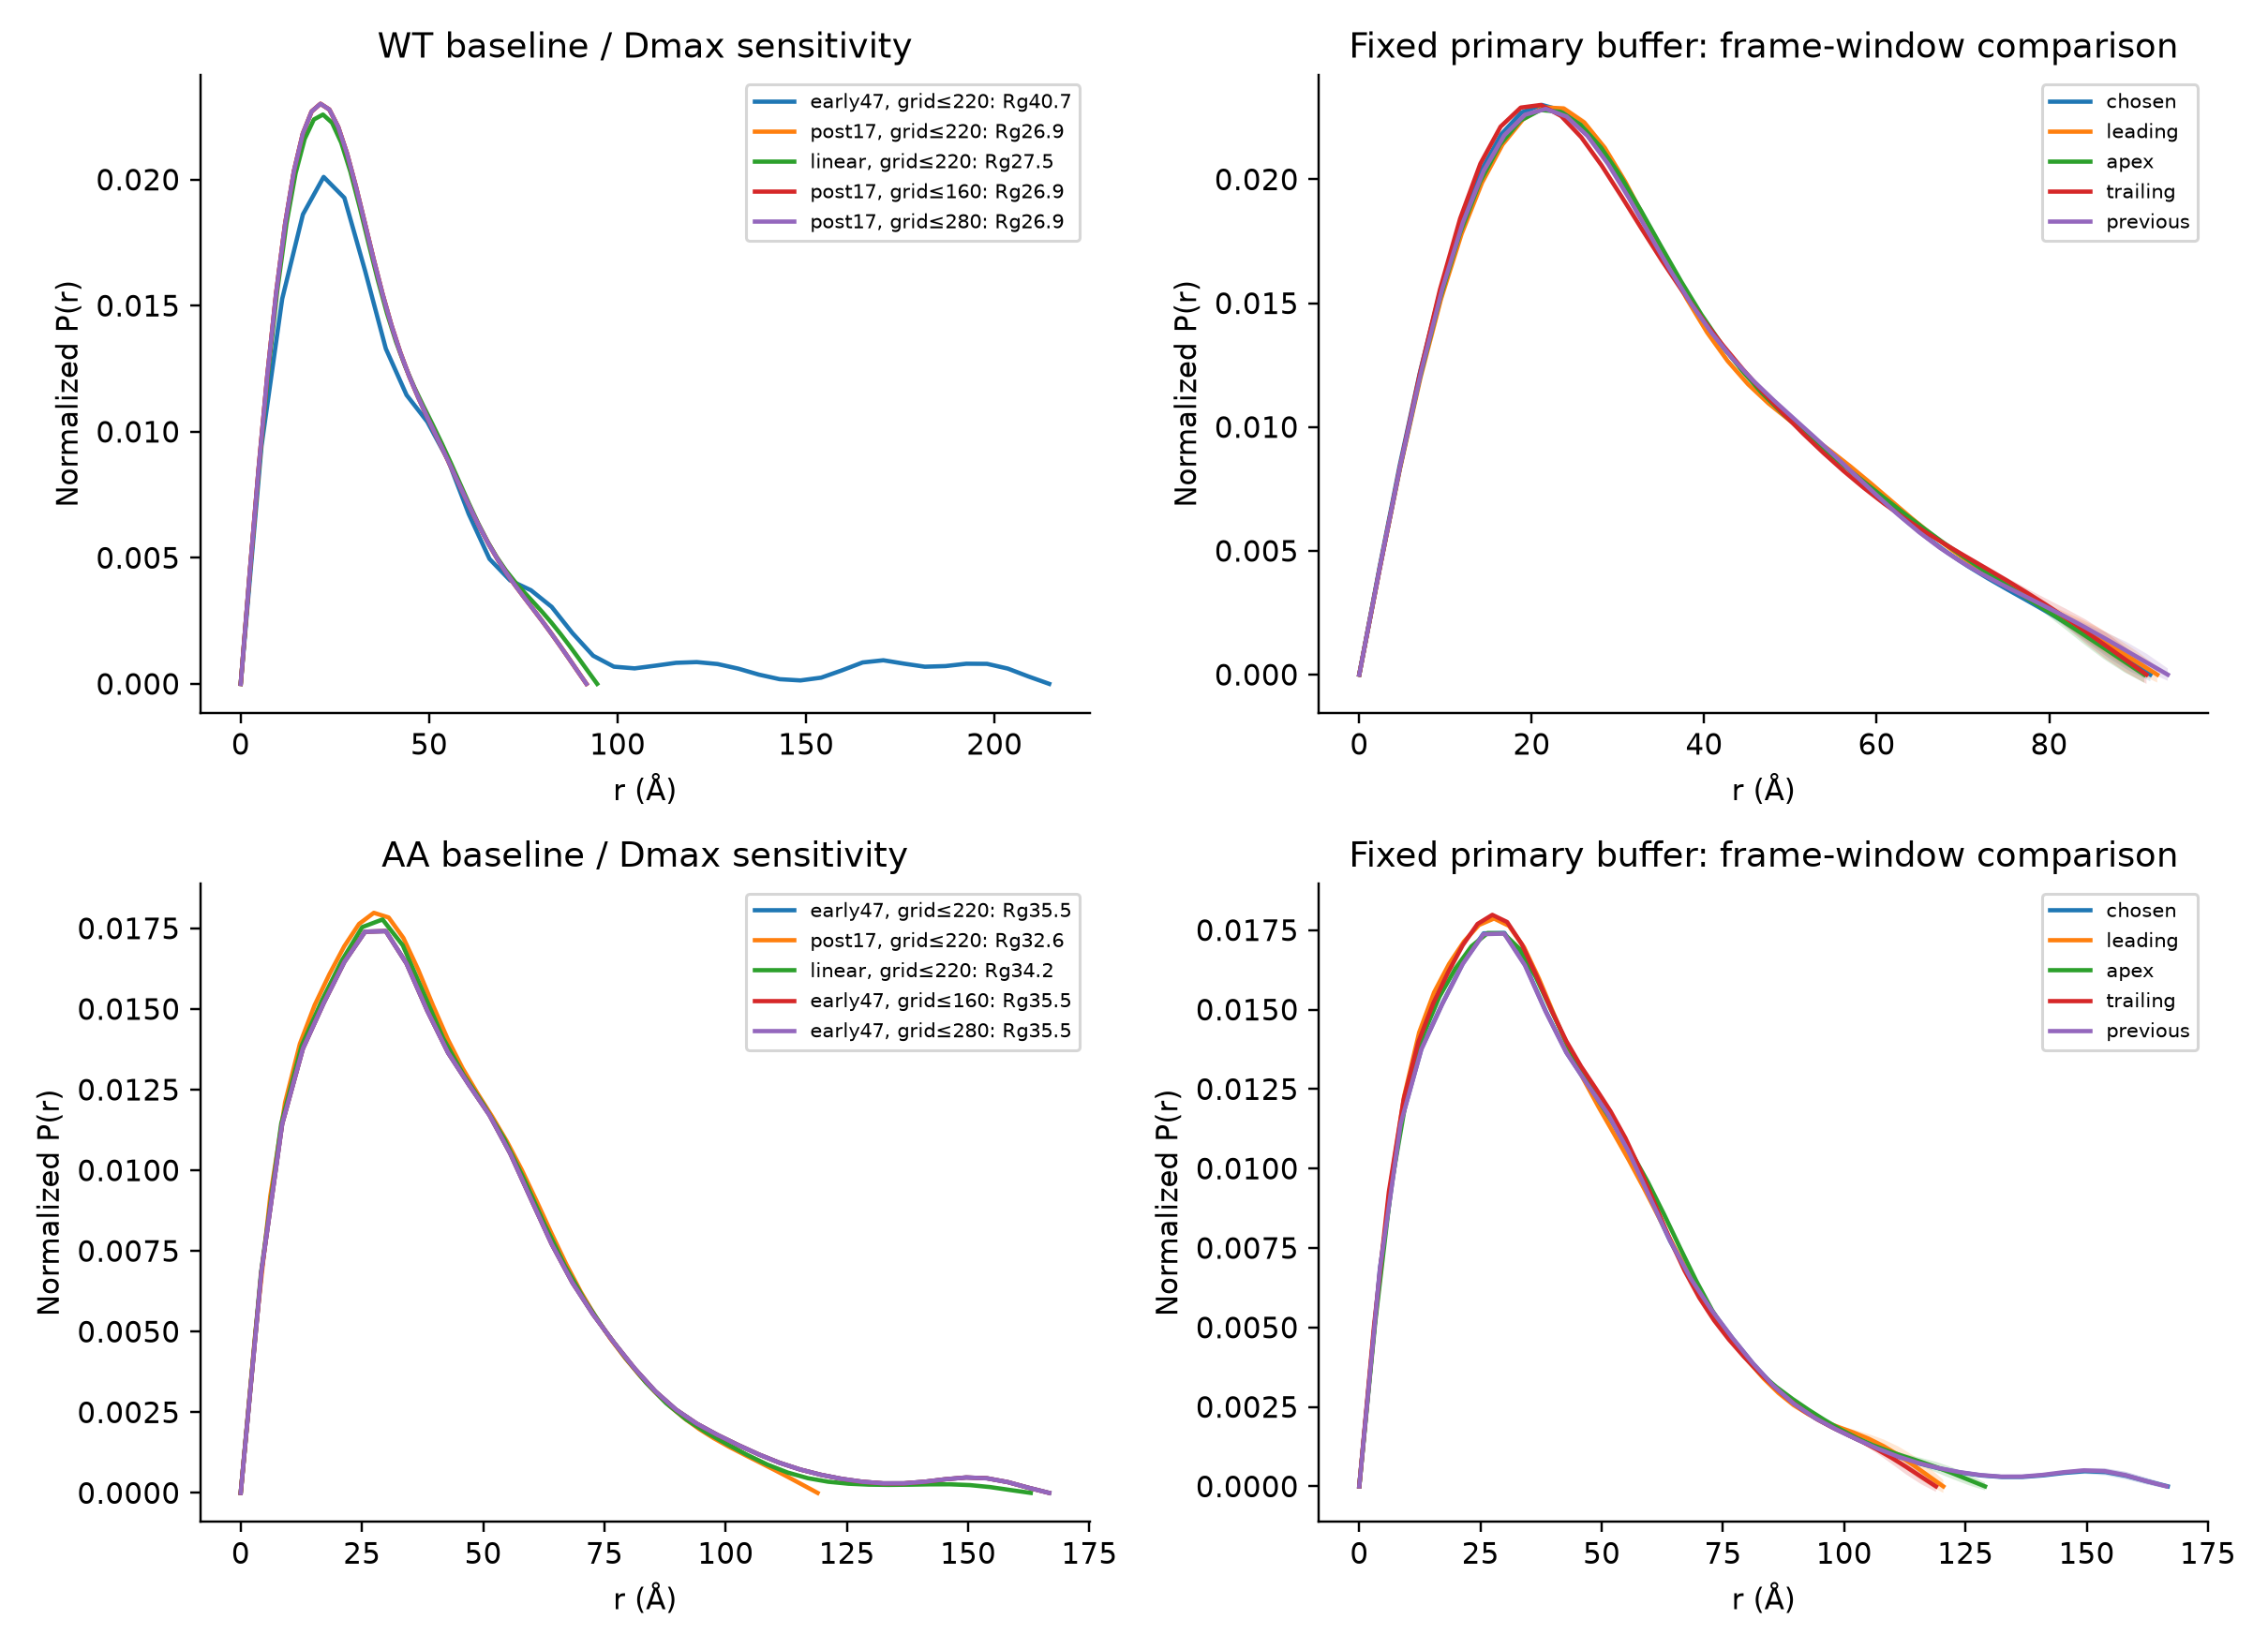

|Sample|Buffer model|Initial search upper (Å)|P(r) Rg (Å)|Dmax (Å)|
|---|---|---:|---:|---:|
|WT|early47|220|40.69|214.5|
|WT|post17|220|26.91|91.7|
|WT|linear|220|27.50|94.6|
|WT|post17|160|26.91|91.7|
|WT|post17|280|26.91|91.7|
|AA|early47|220|35.46|166.7|
|AA|post17|220|32.61|119.0|
|AA|linear|220|34.17|162.9|
|AA|early47|160|35.46|166.7|
|AA|early47|280|35.46|166.7|


In [9]:
display(Image(filename=str(OUT/'05_Pr_controls.png')))
pr=json.loads((OUT/'Pr_sensitivity.json').read_text())
h='|Sample|Buffer model|Initial search upper (Å)|P(r) Rg (Å)|Dmax (Å)|\n|---|---|---:|---:|---:|\n'
for r in pr:
    if r['bift']:h+=f"|{r['sample'][:2]}|{r['model']}|{r['cap']}|{r['bift']['rg']:.2f}|{r['bift']['dmax']:.1f}|\n"
display(Markdown(h))


## Methods, exports, and limits

All plots are exported as PNG and vector PDF in `paper_figures/`. Source curves retain signed intensities and propagated errors in `.dat` files. Selection tables, all EFA failures, a108case support/q-range grid,100refitted source-noise perturbations per sample, and60rank-one noise controls per sample/background are saved alongside them. The notebook defaults to reading computed results and regenerating figures; set `RECOMPUTE=True` above for a full rerun.

**Publication interpretation:** the main-peak WT–AA size difference persists across the tested buffer choices. Exact Rg/P(r) values remain processing-dependent. WT has a reproducible early shoulder pattern; its oligomeric identity and molecular weight are not established here. There is no comparable evidence from these EFA tests for a second AA scattering species. Window-selection uncertainty, unknown correlated q errors, and biological variability are not covered by the conditional confidence intervals.

References: [Zheng & Best, extended Guinier analysis](https://pmc.ncbi.nlm.nih.gov/articles/PMC6093220/); [BioXTAS RAW SEC-SAXS processing](https://bioxtas-raw.readthedocs.io/en/v2.1.0/api/ex_sec_saxs.html); [RAW2 methods and EFA](https://pmc.ncbi.nlm.nih.gov/articles/PMC10557611/).

Natalie-style panels in `paper_figures/natalie_style/` add explicit error bars, transparent points outside Guinier ranges, and a0.6Å⁻¹ scattering overview. Diagnostic singular-value curves remain diagnostics, not fitted parameters with assigned confidence intervals.